# Data Science Final Exam

## Dear Students,<br><br>Welcome to your final exam in data science. Remember that the true essence of data science lies not only in obtaining results but in extracting meaningful insights.<br><br>In this examination we encourage you to focus not just on the output your code generates but on the story it tells. Sometimes, peculiar outcomes can act as beacons, signaling potential issues in your code or data. Rather than dismissing them, consider these anomalies as opportunities to refine your analysis and enhance your problem-solving skills.<br><br>As you progress through the tasks, think of your comments as a roadmap for others to follow your analytical journey. Clearly articulate your intentions before executing code, detail the steps you took, and, most importantly, provide a comprehensive interpretation of your results. A well-documented analysis not only showcases your technical proficiency but also your ability to think critically about the data at hand.<br><br>Remember, data science is not merely about crunching numbers; it's about crafting narratives that guide decision-making. Each line of code you write and every graph you create contributes to a broader story. Make sure your commentary reflects this understanding, and don't hesitate to acknowledge any challenges or uncertainties you encounter along the way.<br><br>Best of luck!

##Import necesssary libraries.

In [144]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import pandas as pd
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

## Task 1. Hypothesis Testing (2 points)


**The data for this task is in `task_1.csv`**

#### Data task_1.csv:
* index - enumeration
* women_1 - weights of women observed (1st group)
* women_2 - weights of women observed (2nd group)
* men - weights of men observed

### 1.1 Check normality assumption for women_1 and women_2.

##Read the data.

In [145]:
df=pd.read_csv('task_1.csv',delimiter=',')
pd.read_csv('task_1.csv',delimiter=',')[:5]

,index,women_1,women_2,men
0,0,73.098928,78.0,88.274204
1,1,73.613758,65.0,85.956865
2,2,56.480751,65.0,66.678725
3,3,81.904591,91.0,69.819411
4,4,67.361169,104.0,75.928297


##Checking for NaN values

In [146]:
missing_values = df.isna().sum()
print(missing_values)
print(df.shape)

index      0
women_1    0
women_2    0
men        0
dtype: int64
(1000, 4)


###We see that there are no Nan values, we can continue working with this data

##Let's build plots to estimate the presence of emissions

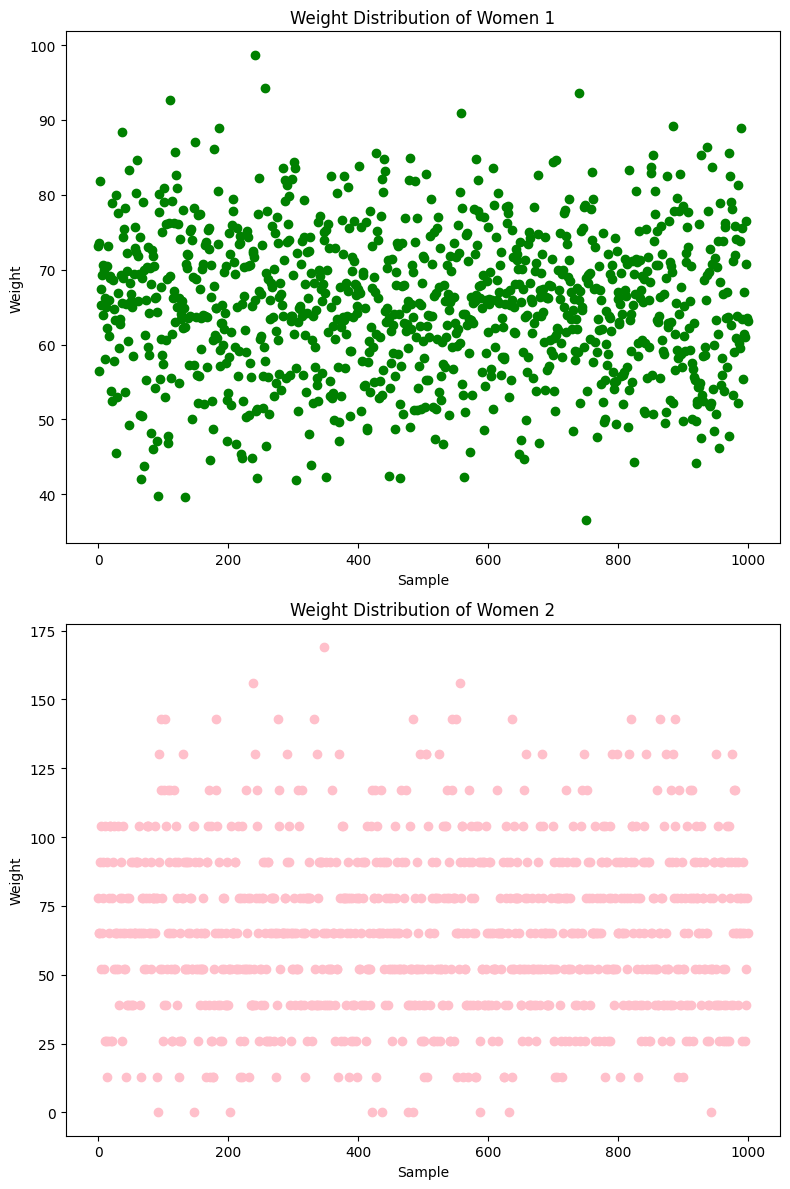

In [147]:
# Создание графика с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12))

# График для women_1
ax1.scatter(x=df.index, y=df['women_1'], label='Women 1', marker='o', color='green')
ax1.set_xlabel('Sample')
ax1.set_ylabel('Weight')
ax1.set_title('Weight Distribution of Women 1')

# График для women_2
ax2.scatter(x=df.index, y=df['women_2'], label='Women 2', marker='o', color='pink')
ax2.set_xlabel('Sample')
ax2.set_ylabel('Weight')
ax2.set_title('Weight Distribution of Women 2')


plt.tight_layout()

plt.show()

##The plots show that there are weights with a value of 0 in the data, but such a weight value can not exist. Conclusion: it is necessary to remove all values with a weight of 0 from the dataset if their number is small compared to the number of rows in the dataset.

In [148]:
zero_counts = df.eq(0).sum()

print("The number of values equal to 0 in each column:")
print(zero_counts)

The number of values equal to 0 in each column:
index       1
women_1     0
women_2    10
men         0
dtype: int64


In [149]:

# Количество строк со значением 0 невелико по сравнению со всем датасетом, поэтому их можно просто удалить и не заполнять
df = df[(df != 0).all(axis=1) | (df['index'] == 0)]
zero_counts = df.eq(0).sum()

print("The number of values equal to 0 in each column:")
print(zero_counts)
df.shape

The number of values equal to 0 in each column:
index      1
women_1    0
women_2    0
men        0
dtype: int64


(990, 4)

##At the beginning, I will analyze the data from the women_1 column in comparison with the normal distribution using a plot.

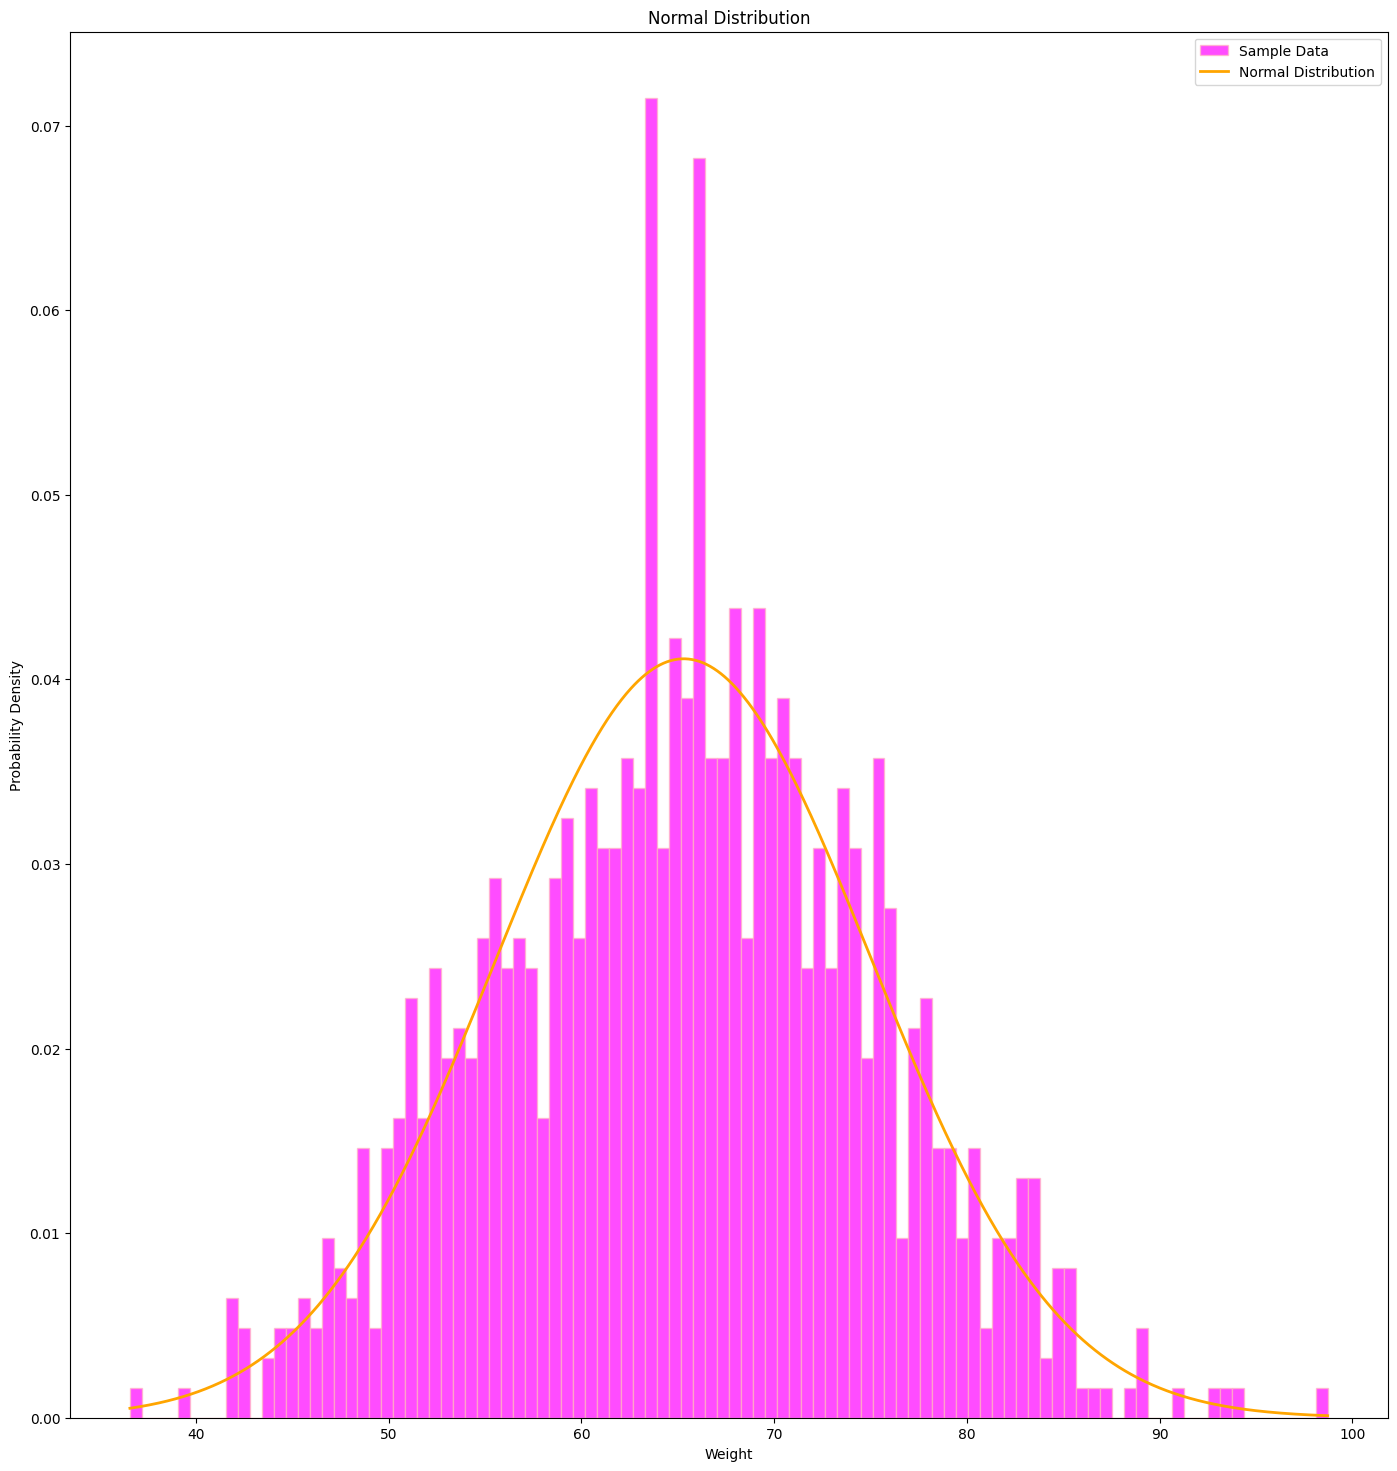

In [150]:

from scipy.stats import norm
from math import pi

plt.figure(figsize=(17, 18))
# Создание гистограммы для сравнения с нормальным распределением
#100 бинов = 100 столбцов, т.к. при меньших значенях графих является крайне неточным(в данной ситуации с 1000 строками в датасете) и делать выводы по нему трудно
count, bins, ignored = plt.hist(df['women_1'], 100, density=True, color='#FF00FF', alpha=0.7, label='Sample Data', edgecolor='lightpink')

mu, sigma = np.mean(df['women_1']), np.std(df['women_1'])
x = np.linspace(np.min(df['women_1']), np.max(df['women_1']), 1000)
pdf = 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (x - mu)**2 / (2 * sigma**2) )
plt.plot(x, pdf, linewidth=2, color='orange', label='Normal Distribution')

# Пересчитываем значения вероятности с учетом шага бина
bin_width = bins[1] - bins[0]
area = np.sum(count * bin_width)
pdf /= area

# Добавление меток и заголовка
plt.xlabel('Weight')
plt.ylabel('Probability Density')
plt.title('Normal Distribution')
plt.legend()

# Отображение графика
plt.show()




##From the plot above, we can conclude that the data is normally distributed, but let's check this idea.

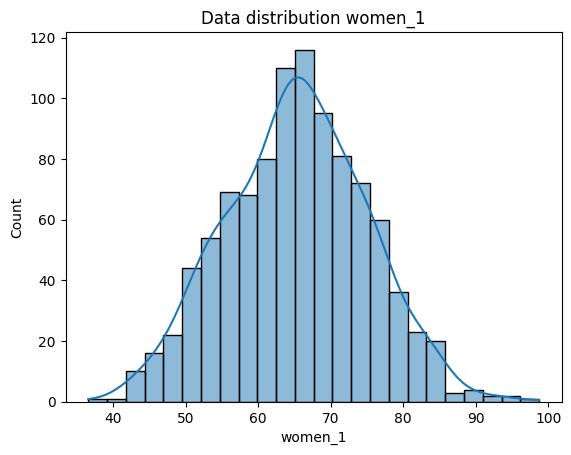

Statistics=0.9982665181159973, p-value=0.42145785689353943
The null hypothesis could not be rejected: the data can be normally distributed


In [151]:
from scipy.stats import shapiro
import seaborn as sns

# Проверка нормальности с использованием теста Шапиро-Уилка
stat, p_value = shapiro(df['women_1'])



# Визуализация распределения данных
"""
KDE (Kernel Density Estimation) - это метод оценки плотности вероятности случайной величины.
В контексте анализа данных и визуализации,
KDE используется для создания сглаженной оценки формы распределения данных.
"""
# kde - добавляет график непрерывной функции плотности вероятности по данным, если бы их значения были бы сглажены
sns.histplot(df['women_1'], kde=True)
plt.title('Data distribution women_1')
plt.show()

# Вывод результатов теста
print(f'Statistics={stat}, p-value={p_value}')

# Проверка уровня значимости(уровень отклонения от нулевой гипотезы)
alpha = 0.05
if p_value > alpha:
    print("The null hypothesis could not be rejected: the data can be normally distributed")
else:
    print("The null hypothesis is rejected: the data are not normally distributed")

##I will analyze the data from the women_2 column in comparison with the normal distribution using a plot.

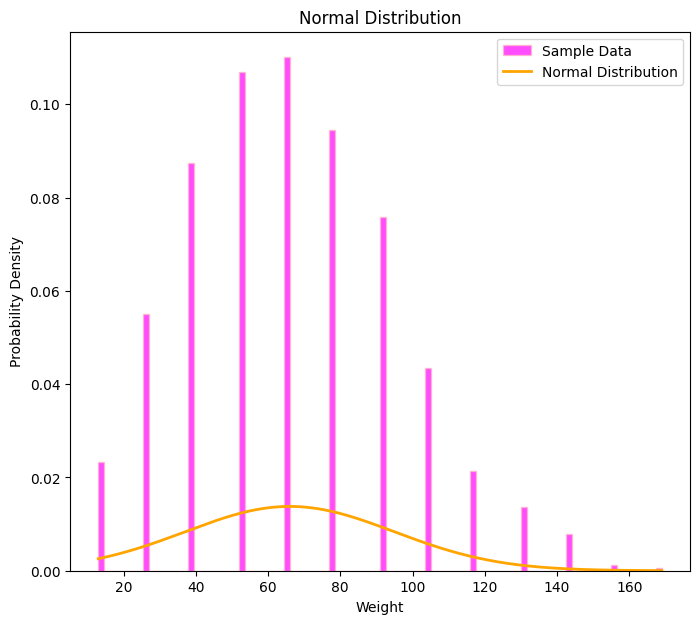

In [152]:

from scipy.stats import norm
from math import pi

plt.figure(figsize=(8, 7))
# Создание гистограммы для сравнения с нормальным распределением
#100 бинов = 100 столбцов, т.к. при меньших значенях графих является крайне неточным(в данной ситуации с 1000) и делать выводы по нему трудно
count, bins, ignored = plt.hist(df['women_2'], 100, density=True, color='#FF00FF', alpha=0.7, label='Sample Data', edgecolor='lightpink')

mu, sigma = np.mean(df['women_2']), np.std(df['women_2'])
x = np.linspace(np.min(df['women_2']), np.max(df['women_2']), 1000)
pdf = 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (x - mu)**2 / (2 * sigma**2) )
plt.plot(x, pdf, linewidth=2, color='orange', label='Normal Distribution')

# Пересчитываем значения вероятности с учетом шага бина
bin_width = bins[1] - bins[0]
area = np.sum(count * bin_width)
pdf /= area

# Добавление меток и заголовка
plt.xlabel('Weight')
plt.ylabel('Probability Density')
plt.title('Normal Distribution')
plt.legend()

# Отображение графика
plt.show()

In [153]:
column_values = df['women_2'].value_counts()

print(column_values)
print(len(column_values))

65.0     170
52.0     165
78.0     146
39.0     135
91.0     117
26.0      85
104.0     67
13.0      36
117.0     33
130.0     21
143.0     12
156.0      2
169.0      1
Name: women_2, dtype: int64
13


##The data from the women_2 set is not distributed normally. But I will check this idea.

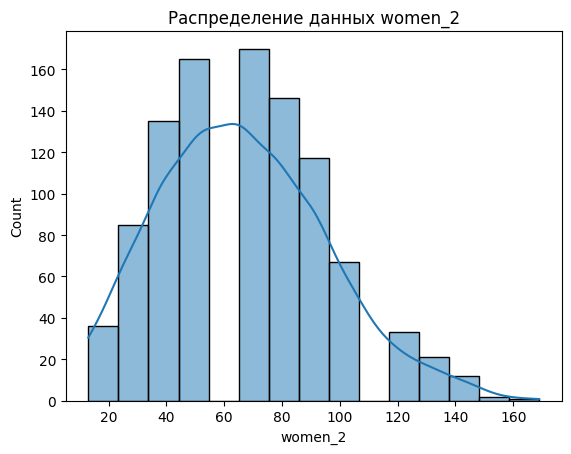

Statistics=0.9686006307601929, p-value=8.627170836441114e-14
The null hypothesis is rejected: the data are not normally distributed


In [154]:
# Проверка нормальности с использованием теста Шапиро-Уилка
stat, p_value = shapiro(df['women_2'])


sns.histplot(df['women_2'], kde=True)
plt.title('Распределение данных women_2')
plt.show()


print(f'Statistics={stat}, p-value={p_value}')

# Проверка уровня значимости(уровень отклонения от нулевой гипотезы)
alpha = 0.05
if p_value > alpha:
    print("The null hypothesis could not be rejected: the data can be normally distributed")
else:
    print("The null hypothesis is rejected: the data are not normally distributed")

##As a result: the data from the women_1 column is distributed normally, and the data from the women_2 column is not distributed normally


### 1.2 Check one of the following hypotheses (based on where the normality assumption is met) using t-test with appropriate paramenters:

**1.**
* HO - women_1 have bigger weight than men
* H1 - they are not

**2.**
* HO - women_2 have the same weight as men
* H1 - they are not

###I will test hypothesis  №1, because the data from the women_1 column corresponds to a normal distribution

In [155]:
import scipy.stats as stats

# t-test
t_statistic, p_value = stats.ttest_ind(df['women_1'], df['men'])

# Уровень значимости обычно 0.05
alpha = 0.05


print("t-statistics:", t_statistic)
print("p-value:", p_value)

# Проверка гипотезы
if p_value < alpha:
    print("We confirm the first hypothesis: there is no reason to believe that the weight of women is greater than the weight of men.")
else:
    print("We confirm the null hypothesis: there is reason to believe that the weight of women is greater than the weight of men.")

t-statistics: -32.31991780582772
p-value: 2.2837032109942446e-184
We confirm the first hypothesis: there is no reason to believe that the weight of women is greater than the weight of men.


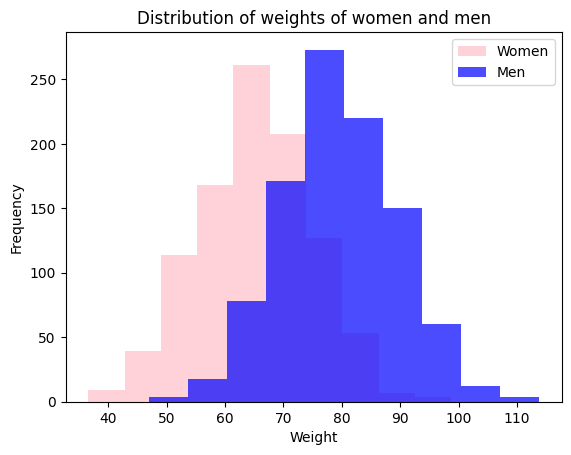

In [156]:


# Распределение весов женщин и мужчин
plt.hist(df["women_1"], color='pink', alpha=0.7, label='Women')
plt.hist(df["men"], color='blue', alpha=0.7, label='Men')

plt.title('Distribution of weights of women and men')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.legend()

plt.show()


## Task 2. ANOVA (2 points)

Calcium is an essential mineral that regulates the heart, is important for blood clotting and for building healthy bones. The National Osteoporosis Foundation recommends a daily calcium intake of 1000-1200 mg/day for adult men and women. While calcium is contained in some foods, most adults do not get enough calcium in their diets and take supplements. Unfortunately some of the supplements have side effects such as gastric distress, making them difficult for some patients to take on a regular basis.  

 A study is designed to test whether there is a difference in mean daily calcium intake in adults with normal bone density, adults with osteopenia (a low bone density which may lead to osteoporosis) and adults with osteoporosis. Adults 60 years of age with normal bone density, osteopenia and osteoporosis are selected at random from hospital records and invited to participate in the study. Each participant's daily calcium intake is measured based on reported food intake and supplements. The data are shown below.

Key steps to follow:

* Checking assumptions for ANOVA
* Performing Anova
* Interpret the results (in markdown or as a comment)

In [157]:
anova_raw = {
    'Normal Bone Density': [1200, 1000, 980, 900, 750, 800],
    'Osteopenia': [1000, 1100, 700, 800, 500, 700],
    'Osteoporosis': [890, 650, 1100, 900, 400, 350]
}

### 2.1 Check assumptions for normality using Shapiro-Wilk test

In [158]:
from scipy.stats import shapiro

alpha = 0.05



for group, data in anova_raw.items():
    stat, p = shapiro(data)
    print(f'Shapiro-Wilk test for the group {group}: statistics={stat}, p-value={p}')
    if p > alpha:
        print(f'Data from the group {group} have a normal distribution (we do not reject the null hypothesis)')
    else:
        print(f'Data from the group {group} they do not have a normal distribution (we reject the null hypothesis)')

    print('-'*40)


Shapiro-Wilk test for the group Normal Bone Density: statistics=0.9554205536842346, p-value=0.7838440537452698
Data from the group Normal Bone Density have a normal distribution (we do not reject the null hypothesis)
----------------------------------------
Shapiro-Wilk test for the group Osteopenia: statistics=0.9552927613258362, p-value=0.7828279137611389
Data from the group Osteopenia have a normal distribution (we do not reject the null hypothesis)
----------------------------------------
Shapiro-Wilk test for the group Osteoporosis: statistics=0.921475887298584, p-value=0.5160539150238037
Data from the group Osteoporosis have a normal distribution (we do not reject the null hypothesis)
----------------------------------------


##From the messages displayed on the screen, it can be seen that the variables in each group are distributed normally ((we can continue the steps to checking assumptions for ANOVA))

### 2.2 Сheck the assumption of homogeneity of variances

In [159]:
!pip install pingouin


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.9/198.9 kB 1.8 MB/s eta 0:00:00


##I will use Levene's test for this task as it was in 05_03_anova.ipynb.

In [160]:
import pingouin as pg
df = pd.DataFrame(anova_raw)

result = pg.homoscedasticity(data=df).round(2)
print(result)

           W  pval  equal_var
levene  1.63  0.23       True


##We assume that the value of equal_var is True. This means that the null hypothesis of equality of variances has been accepted. We can continue the steps to checking assumptions for ANOVA.

### 2.3 Perform ANOVA and interpret the results

In [161]:
import pandas as pd
import pingouin as pg


# Преобразование данных в длинный формат
df_melt = df.melt(var_name='Group', value_name='Value')


print(df_melt)

# Проведение однофакторного дисперсионного анализа (ANOVA)
pg.anova(data=df_melt, dv='Value', between='Group', detailed=True)


                  Group  Value
0   Normal Bone Density   1200
1   Normal Bone Density   1000
2   Normal Bone Density    980
3   Normal Bone Density    900
4   Normal Bone Density    750
5   Normal Bone Density    800
6            Osteopenia   1000
7            Osteopenia   1100
8            Osteopenia    700
9            Osteopenia    800
10           Osteopenia    500
11           Osteopenia    700
12         Osteoporosis    890
13         Osteoporosis    650
14         Osteoporosis   1100
15         Osteoporosis    900
16         Osteoporosis    400
17         Osteoporosis    350


,Source,SS,DF,MS,F,p-unc,np2
0,Group,152477.777778,2,76238.888889,1.394897,0.278229,0.15682
1,Within,819833.333333,15,54655.555556,NaN,NaN,NaN


####(The value of "NaN" for Within indicates that there is no available information about the F-value and p-value for intra-group variability. This is because in ANOVA, intragroup variability is used as a baseline for comparison with intergroup variability. Therefore, the F-value and p-value are not calculated for Within, since it makes no sense to compare it with itself. Instead, only intergroup differences are analyzed.)



##We determine whether we can reject the null hypothesis based on the value of the p-value.

##In this case, the value of the p-value is 0.2782, which is greater than 0.05, which means that we do not have enough evidence to reject the null hypothesis.

## Task 3. Linear Regression

Given the Dataset in `task_3.csv` make some necessary transformations and train regression model to predict flight tickets' price.

### Dataset Description

The objective of the study is to analyse the flight booking dataset obtained from “Ease My Trip” website and to conduct various statistical hypothesis tests in order to get meaningful information from it. The 'Linear Regression' statistical algorithm would be used to train the dataset and predict a continuous target variable. 'Easemytrip' is an internet platform for booking flight tickets, and hence a platform that potential passengers use to buy tickets. A thorough study of the data will aid in the discovery of valuable insights that will be of enormous value to passengers.

**Dataset**
Dataset contains information about flight booking options from the website Easemytrip for flight travel between India's top 6 metro cities. There are 300261 datapoints and 11 features in the cleaned dataset.

**Features**

The various features of the cleaned dataset are explained below:

1) Airline: The name of the airline company is stored in the airline column. It is a categorical feature having 6 different airlines.
2) Flight: Flight stores information regarding the plane's flight code. It is a categorical feature.
3) Source City: City from which the flight takes off. It is a categorical feature having 6 unique cities.
4) Departure Time: This is a derived categorical feature obtained created by grouping time periods into bins. It stores information about the departure time and have 6 unique time labels.
5) Stops: A categorical feature with 3 distinct values that stores the number of stops between the source and destination cities.
6) Arrival Time: This is a derived categorical feature created by grouping time intervals into bins. It has six distinct time labels and keeps information about the arrival time.
7) Destination City: City where the flight will land. It is a categorical feature having 6 unique cities.
8) Class: A categorical feature that contains information on seat class; it has two distinct values: Business and Economy.
9) Duration: A continuous feature that displays the overall amount of time it takes to travel between cities in hours.
10) Days Left: This is a derived characteristic that is calculated by subtracting the trip date by the booking date.
11) Price: Target variable stores information of the ticket price.

*Dataset is already cleaned*


In [162]:
df=pd.read_csv('task_3.csv',delimiter=',')
pd.read_csv('task_3.csv',delimiter=',')[:5]

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


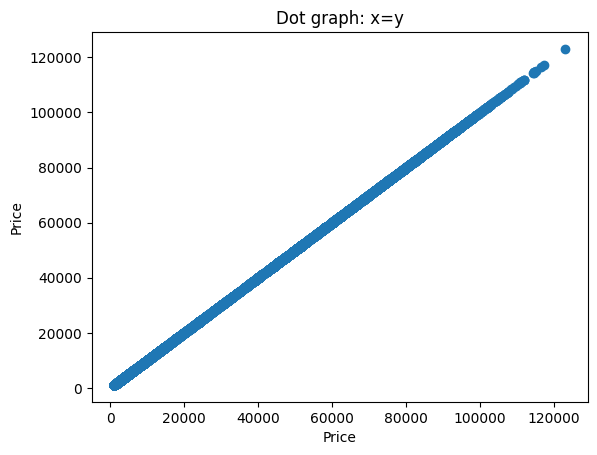

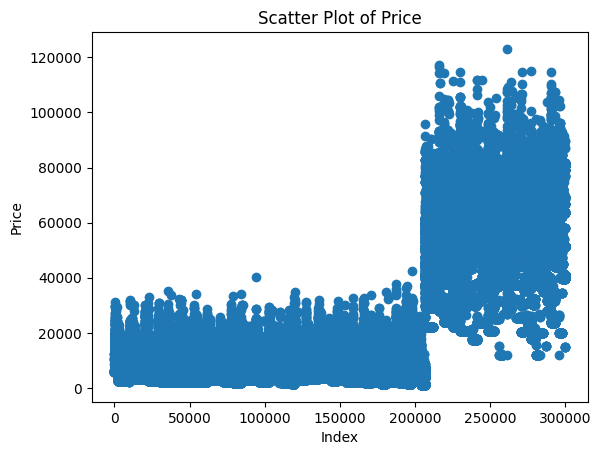

In [163]:
plt.scatter(df['price'], df['price'])

plt.xlabel('Price')
plt.ylabel('Price')
plt.title('Dot graph: x=y')
plt.show()

plt.scatter(df.index, df['price'])
plt.xlabel('Index')
plt.ylabel('Price')
plt.title('Scatter Plot of Price')
plt.show()



##Before working with the dataset, I will create the simplest linear regression on the data processed through ohe

In [164]:
'''
Вручную подбирала параметры, чтобы посмотреть, что лин регрессия вообще работает ли
Вывод: при наличии столбца 'flight' в таком списке столбцов:selected_columns = ['class',
'airline','price','stops','arrival_time','departure_time','source_city','flight'] модель линейной регрессии
работает некорректно на данном датасете: отриц R-squared.
'''

'''
Однако, рейс ведь в себя включает и информацию о авиакомпании, и о городе откуда летит самолёт, и куда он летит, и о времени вылета и т.д.,
т.е. о всех параметрах кроме класса, т.к. на одном рейсе могут быть разные классы. Однако такая модель тоже показывает некорретные данные -
отриц R-squared
'''


selected_columns = ['flight','price','class']

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# Создаем новый датасет, включающий только выбранные столбцы
X = df.loc[:, selected_columns]
categorical_columns = X.select_dtypes(include=['object']).columns

# Применяем One-Hot Encoding ко всем категориальным столбцам
X = pd.get_dummies(X, columns=categorical_columns)
nan_counts = X.isna().sum()
X = X.dropna()
y=X['price']
X = X.drop('price', axis=1)



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')








Mean Squared Error: 1.5399710406190049e+26
R-squared: -2.9874374339920966e+17


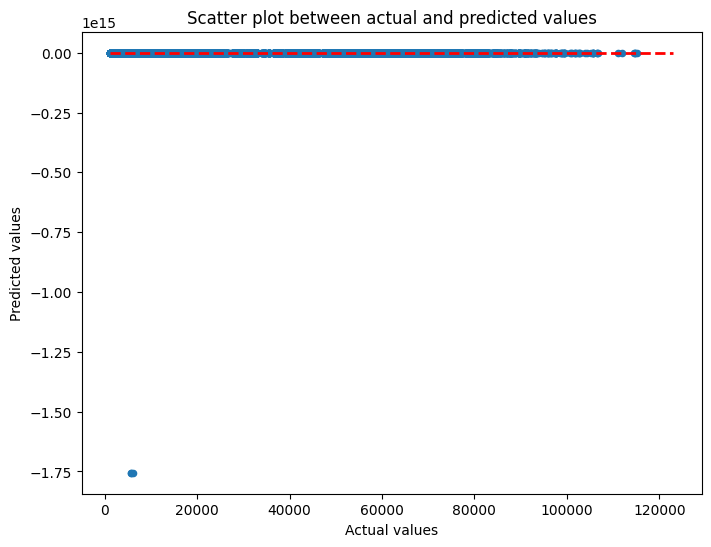

In [165]:

# Построение графика рассеяния
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, s=20)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Scatter plot between actual and predicted values")
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', linewidth=2)
plt.show()



##Analyzing the plot above, the theory was confirmed: on the data in which the flight column is included, the lin regression model does not work correctly. Conclusion: it is necessary to delete this column

### 3.1 Data Transformation:

- Transform categorical variables to numeric form. Decide on the most appropriate method, such as one-hot encoding, label encoding, or any other relevant technique.
- Provide justifications for the chosen transformation method and discuss any variables that might be excluded.

##Since it is said that the dataset is clean, there is no need to check the data and you can immediately start converting them.

In [166]:
column_names = df.columns.tolist()
print(column_names)

# Отбираем категориальные столбцы
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

# Отбираем числовые столбцы
numerical_columns = df.select_dtypes(include=['int', 'float']).columns.tolist()


['index', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']


##I will consider each feature and convert it to numeric values.

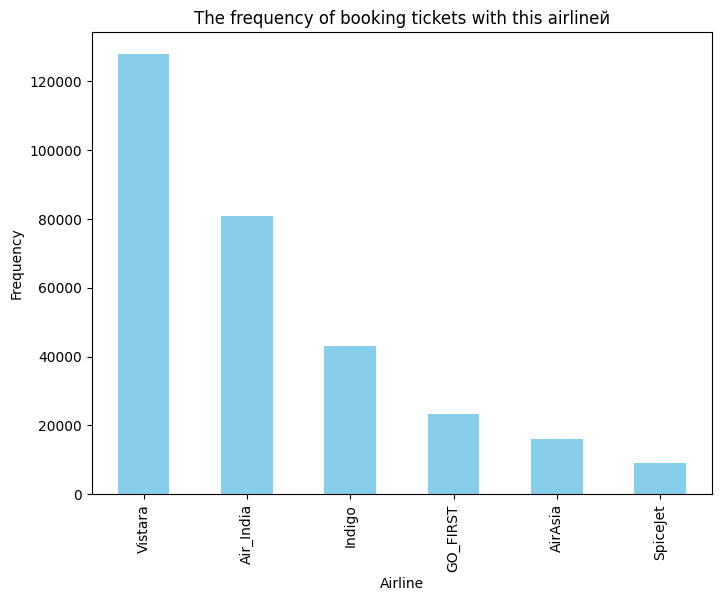

In [167]:
"""
Преобразование столбца с авиакомпаниями.
Постою диаграмму, чтобы оценить данные по авиакомпаниям.
"""

airline_counts = df['airline'].value_counts()

# Построение диаграммы
plt.figure(figsize=(8, 6))
airline_counts.plot(kind='bar', color='skyblue')
plt.title('The frequency of booking tickets with this airlineй')
plt.xlabel('Airline')
plt.ylabel('Frequency')
plt.show()


df=df.drop('flight',axis=1)

In [168]:

'''
Изначальная идея:
'''
"""
 Есть упорядоченность между компаниями(по количеству рейсов).Поэтому приоритет расставлен от
 колич. брон билетов - больше брон билетов - больше приоритет компании, ведь чем больше людей доверились этой компании,
 будем считать что, тем она надёжнее. Поэтому тут буду использовать LabelEncode.
"""
'''
priorities = {'Vistara': 6, 'Air_India': 5, 'Indigo': 4,'GO_FIRST':3,'AirAsia':2,'SpiceJet':1}

Результат который был:
Mean Squared Error: 45983061.74767098
R-squared: 0.910796036827196
'''

'''
Следующая идея:
'''

'''
После составления различных графиков, в частности реализации идеи создания диаграммы зависимости цены билета за эконом класс
(график реализован в задании 3.3, где необходимо было создать полезные графики), я решила поменять приоритет компаний,где выше приоритет,
там выше средняя стоимость за билет в эконом классе(т.к. билеты бизнес класса встречаются лишь в 2 компаниях)
priorities = {'Vistara': 6, 'Air_India': 6, 'Indigo': 4,'GO_FIRST':4,'AirAsia':2,'SpiceJet':4}
Результат:
Mean Squared Error: 52542563.87035517
R-squared: 0.898071055854969
Вывод: идея не подтвердилась, первая гораздо лучше(результаты ниже :) ).
'''


priorities = {'Vistara': 6, 'Air_India': 5, 'Indigo': 4,'GO_FIRST':3,'AirAsia':2,'SpiceJet':1}

# Применение Label Encoding с учетом приоритетов
label_encoder = LabelEncoder()
df['airline'] = df['airline'].map(lambda x: priorities[x])


In [169]:
print(df)

         index  airline source_city departure_time stops   arrival_time  \
0            0        1       Delhi        Evening  zero          Night   
1            1        1       Delhi  Early_Morning  zero        Morning   
2            2        2       Delhi  Early_Morning  zero  Early_Morning   
3            3        6       Delhi        Morning  zero      Afternoon   
4            4        6       Delhi        Morning  zero        Morning   
...        ...      ...         ...            ...   ...            ...   
300148  300148        6     Chennai        Morning   one        Evening   
300149  300149        6     Chennai      Afternoon   one          Night   
300150  300150        6     Chennai  Early_Morning   one          Night   
300151  300151        6     Chennai  Early_Morning   one        Evening   
300152  300152        6     Chennai        Morning   one        Evening   

       destination_city     class  duration  days_left  price  
0                Mumbai   Economy  

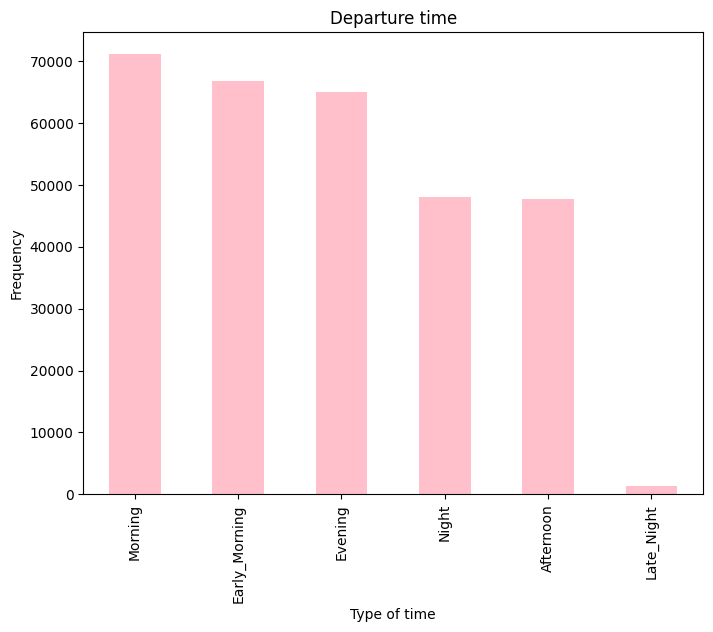

In [170]:
"""
Преобразование времени отправления
"""
airline_counts = df['departure_time'].value_counts()

# Построение диаграммы
plt.figure(figsize=(8, 6))
airline_counts.plot(kind='bar', color='pink')
plt.title('Departure time')
plt.xlabel('Type of time')
plt.ylabel('Frequency')
plt.show()


In [171]:
# Изучив график можно сделать вывод, что 6 времён отправления можно разделить на 3 группы приоритета:
# чаще всего вылет - утром, ранним утром и вечером,
# средне - ночью и днём, меньше всего - поздней ночью
# поэтому для departure_time буду использовать LabelEncoder


priorities = {'Morning': 3, 'Early_Morning': 3, 'Evening': 3,'Night':2,'Afternoon':2,'Late_Night':1}

# Применение Label Encoding с учетом приоритетов
label_encoder = LabelEncoder()
df['departure_time'] = df['departure_time'].map(lambda x: priorities[x])

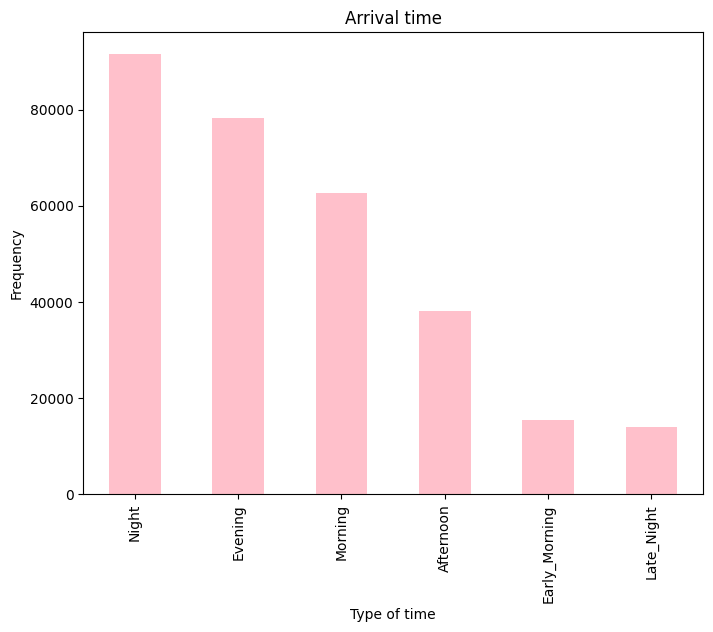

In [172]:
"""
Преобразование времени пребытия
"""
airline_counts = df['arrival_time'].value_counts()

# Построение диаграммы
plt.figure(figsize=(8, 6))
airline_counts.plot(kind='bar', color='pink')
plt.title('Arrival time')
plt.xlabel('Type of time')
plt.ylabel('Frequency')
plt.show()

In [173]:
# Изучив график можно сделать вывод, что 6 времён отправления можно разделить на 5 групп приоритета(по времени суток).
# поэтому для arrival_time буду использовать LabelEncoder.


priorities = {'Morning': 3, 'Early_Morning': 1, 'Evening': 4,'Night':5,'Afternoon':2,'Late_Night':1}

# Применение Label Encoding с учетом приоритетов
label_encoder = LabelEncoder()
df['arrival_time'] = df['arrival_time'].map(lambda x: priorities[x])

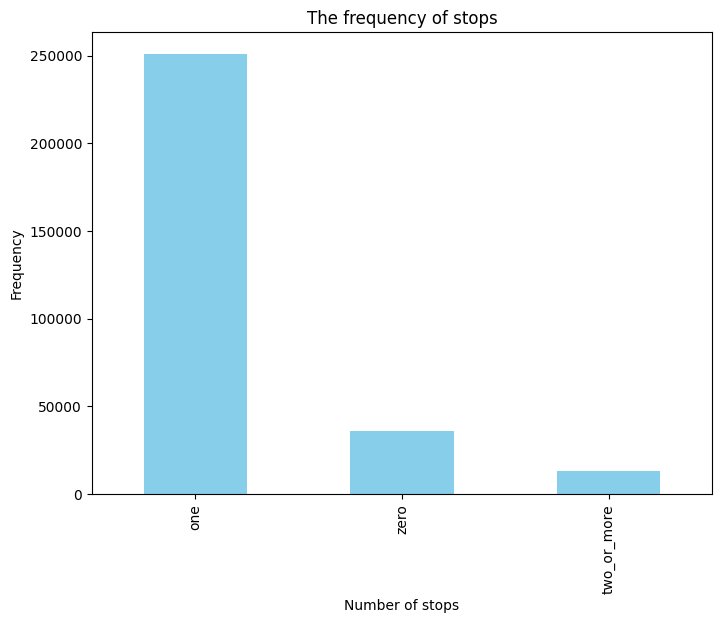

In [174]:

"""
Преобразование кол остановок
"""


airline_counts = df['stops'].value_counts()

# Построение диаграммы
plt.figure(figsize=(8, 6))
airline_counts.plot(kind='bar', color='skyblue')
plt.title('The frequency of stops')
plt.xlabel('Number of stops')
plt.ylabel('Frequency')
plt.show()



In [175]:
unique_values = df['stops'].unique()
priorities = {'one': 3, 'zero': 1, 'two_or_more': 1}

# Применение Label Encoding с учетом приоритетов
label_encoder = LabelEncoder()
df['stops'] = df['stops'].map(lambda x: priorities[x])

In [176]:
print(df)

         index  airline source_city  departure_time  stops  arrival_time  \
0            0        1       Delhi               3      1             5   
1            1        1       Delhi               3      1             3   
2            2        2       Delhi               3      1             1   
3            3        6       Delhi               3      1             2   
4            4        6       Delhi               3      1             3   
...        ...      ...         ...             ...    ...           ...   
300148  300148        6     Chennai               3      3             4   
300149  300149        6     Chennai               2      3             5   
300150  300150        6     Chennai               3      3             5   
300151  300151        6     Chennai               3      3             4   
300152  300152        6     Chennai               3      3             4   

       destination_city     class  duration  days_left  price  
0                Mumbai

In [177]:
'''
В признаках же flight, source_city, destination_city, class нет зависимости между различными значениями поэтому для них применю OHE
Однако по причинам, объяснённым выше, столбец flight не будет включен в конечный датасет
'''
#ohe
df = pd.get_dummies(df, columns=[ 'source_city','destination_city','class'], prefix=['source_city','destination_city','class'])

In [178]:

'''
Проверяем остались ли категориальные столбцы с данными
'''

categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
numerical_columns = df.select_dtypes(include=['int', 'float']).columns.tolist()


print(categorical_columns,numerical_columns)

[] ['index', 'airline', 'departure_time', 'stops', 'arrival_time', 'duration', 'days_left', 'price']


In [179]:
print(df)

         index  airline  departure_time  stops  arrival_time  duration  \
0            0        1               3      1             5      2.17   
1            1        1               3      1             3      2.33   
2            2        2               3      1             1      2.17   
3            3        6               3      1             2      2.25   
4            4        6               3      1             3      2.33   
...        ...      ...             ...    ...           ...       ...   
300148  300148        6               3      3             4     10.08   
300149  300149        6               2      3             5     10.42   
300150  300150        6               3      3             5     13.83   
300151  300151        6               3      3             4     10.00   
300152  300152        6               3      3             4     10.08   

        days_left  price  source_city_Bangalore  source_city_Chennai  ...  \
0               1   5953          

####It can be seen that the list with categorical data is empty, so now all the data is numeric and we can proceed to the next step.

### 3.2 Visualization of Variables:

- Visualize the correlation between variables. Use techniques like correlation matrices or heatmap to represent relationships between different features.
- Discuss any interesting observations or patterns identified during visualization.

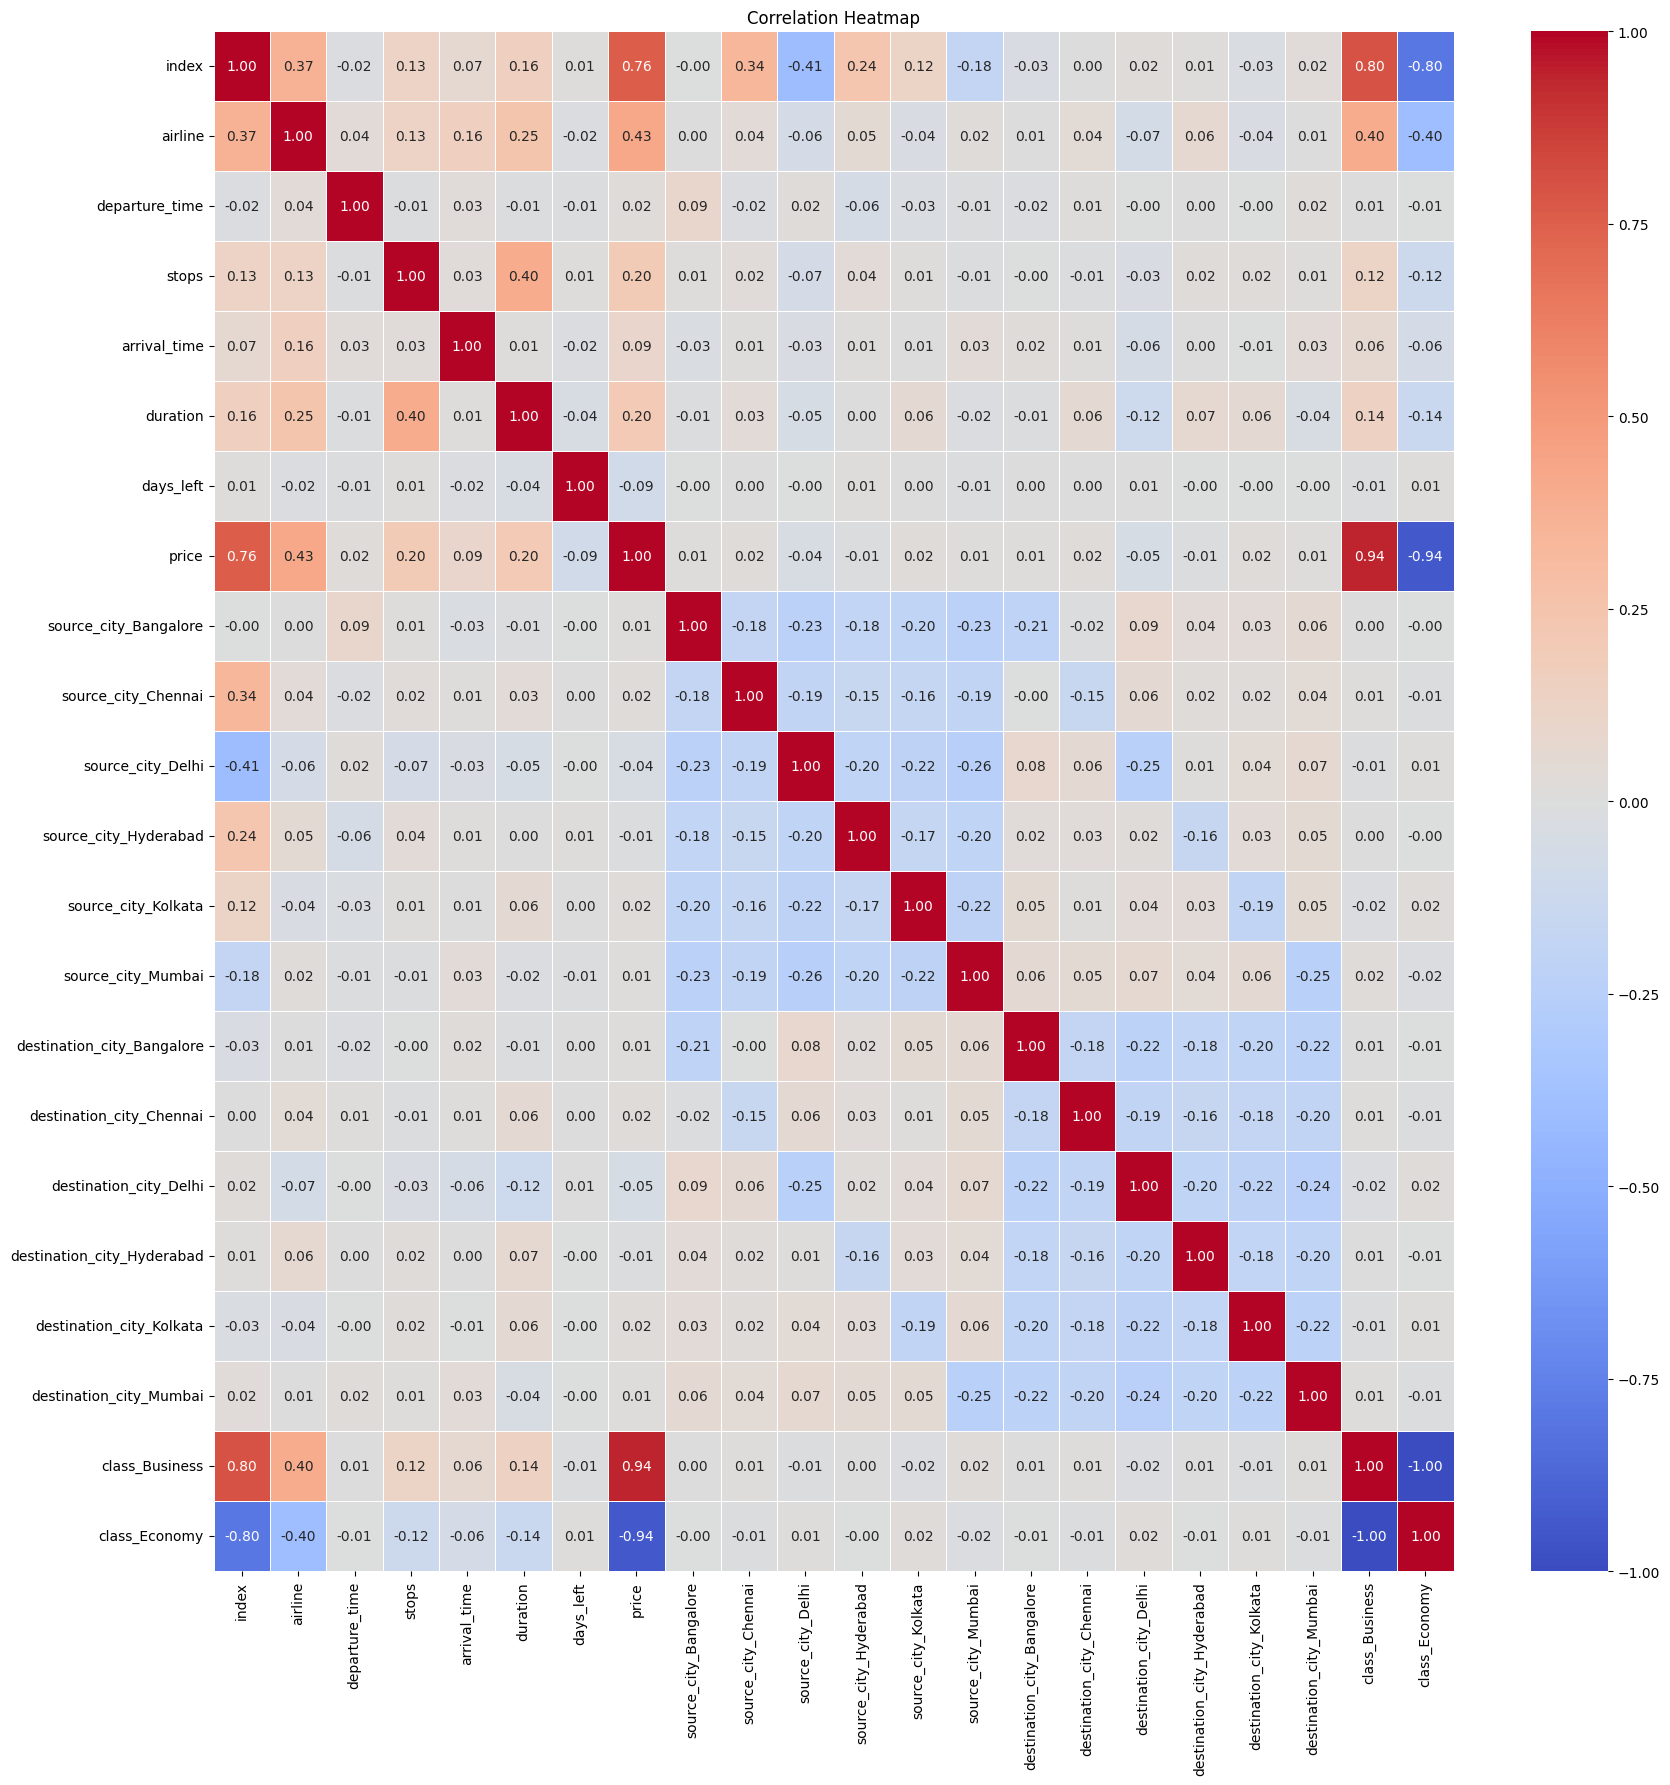

In [180]:
import seaborn as sns
import matplotlib.pyplot as plt

# Создание матрицы корреляции
correlation_matrix = df.corr()

# Создание тепловой карты
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

##Having considered the heat map of the correlation matrix. The following conclusions can be drawn: the following parameters most strongly affect the ticket price: class tickets and airline.
##Moreover, these parameters are interrelated. Therefore, in the future I will try to add an additional feature based on these 2 parameters.
##The number of stops and the duration of the flight also affect each other. And these 2 parameters also affect the cost, so I will make an additional feature based on these 2 parameters

### 3.3 Optional Graphs:

- Create additional graphs that you find helpful and insightful for understanding the dataset.
- Examples of optional graphs include distribution plots, box plots, or any other visualization that might provide useful insights.

<ipython-input-181-e0a2e07ae50f>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='airline', y='price', data=average_prices, palette='viridis')


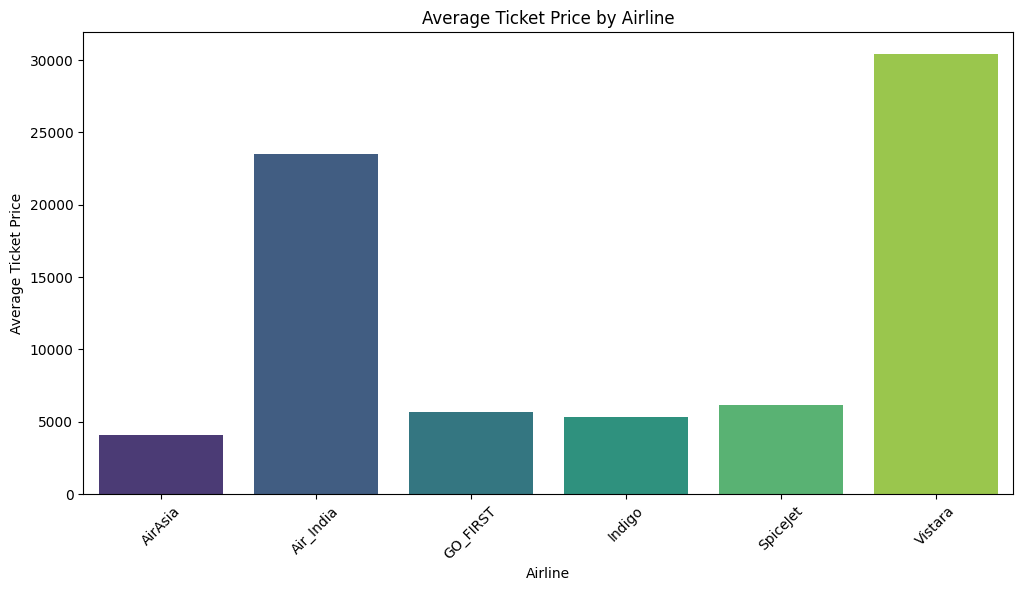

In [181]:
#чтобы можно было делать зависимости по изначальному датасету
dop_df=pd.read_csv('task_3.csv',delimiter=',')

# Группировка данных по авиакомпаниям и вычисление средней цены билета для каждой из них
average_prices = dop_df.groupby('airline')['price'].mean().reset_index()

# Строим график
plt.figure(figsize=(12, 6))
sns.barplot(x='airline', y='price', data=average_prices, palette='viridis')
plt.title('Average Ticket Price by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Ticket Price')
plt.xticks(rotation=45)
plt.show()


##It can be seen that 2 airlines (Vistara,Air_India) have the most expensive tickets. Since the ticket price depends quite heavily on the ticket price, we will check each company for the number of economy class and business class tickets

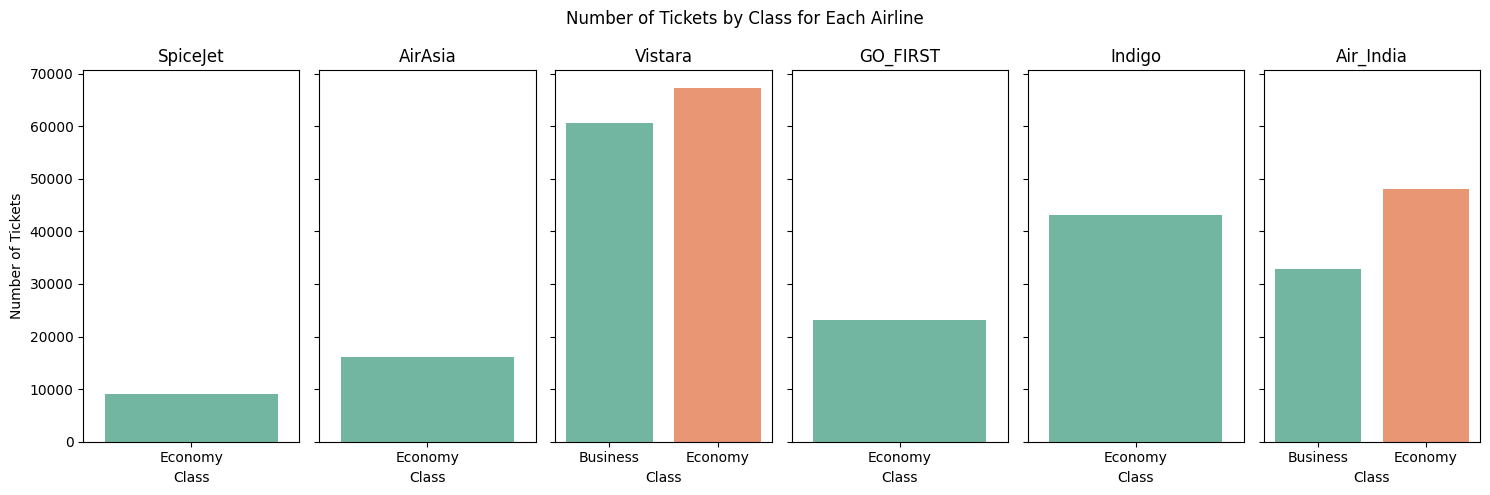

In [182]:
'''
 Диаграммы по соотношению кол билетов бизнес класса и эконом класса по различным авиакомпаниям
'''

# Создаем сетку графиков
fig, axes = plt.subplots(nrows=1, ncols=len(dop_df['airline'].unique()), figsize=(15, 5), sharey=True)

# Проходимся по каждой авиакомпании
for i, airline in enumerate(dop_df['airline'].unique()):
    # Фильтруем данные для текущей авиакомпании
    filtered_data = dop_df[dop_df['airline'] == airline]
    # Группируем данные по классу билета и считаем количество билетов для каждого класса
    ticket_counts = filtered_data.groupby('class')['class'].count().reset_index(name='count')
    # Строим диаграмму для текущей авиакомпании
    sns.barplot(x='class', y='count', hue='class', data=ticket_counts, ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(f'{airline}')
    axes[i].set_xlabel('Class')
    axes[i].set_ylabel('Number of Tickets')

# Добавляем общий заголовок
plt.suptitle('Number of Tickets by Class for Each Airline')

# Располагаем графики без пересечений
plt.tight_layout()

plt.show()


##Now it can be seen that only these 2 airlines provide business class tickets, so the average price for a ticket is higher for them. The company also has almost the same number of business class and economy class tickets, which makes the average cost per ticket in this company the highest. Because the price for a business class ticket is higher than the cost of an economy class ticket.

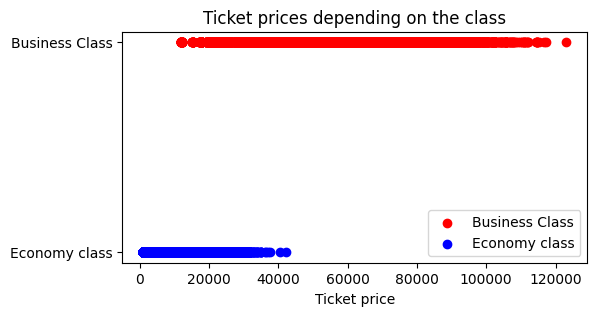

In [183]:

'''
График распределения цен в засисимости от класса билета
'''
import matplotlib.pyplot as plt

class_Business = df['class_Business']
class_Econom = df['class_Economy']
prices = df['price']

plt.figure(figsize=(6, 3))

# Строим точки для бизнес-класса (красные точки)
plt.scatter(prices[class_Business == 1], [1]*sum(class_Business), color='red', label='Business Class')

# Строим точки для эконом-класса (синие точки)
plt.scatter(prices[class_Econom == 1], [0]*sum(class_Econom), color='blue', label='Economy class')

plt.yticks([0, 1], ['Economy class', 'Business Class'])
plt.xlabel('Ticket price')
plt.title('Ticket prices depending on the class')
plt.legend()
plt.show()


<ipython-input-184-62f23e3b3ef1>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='airline', y='price', data=average_prices, palette='viridis')


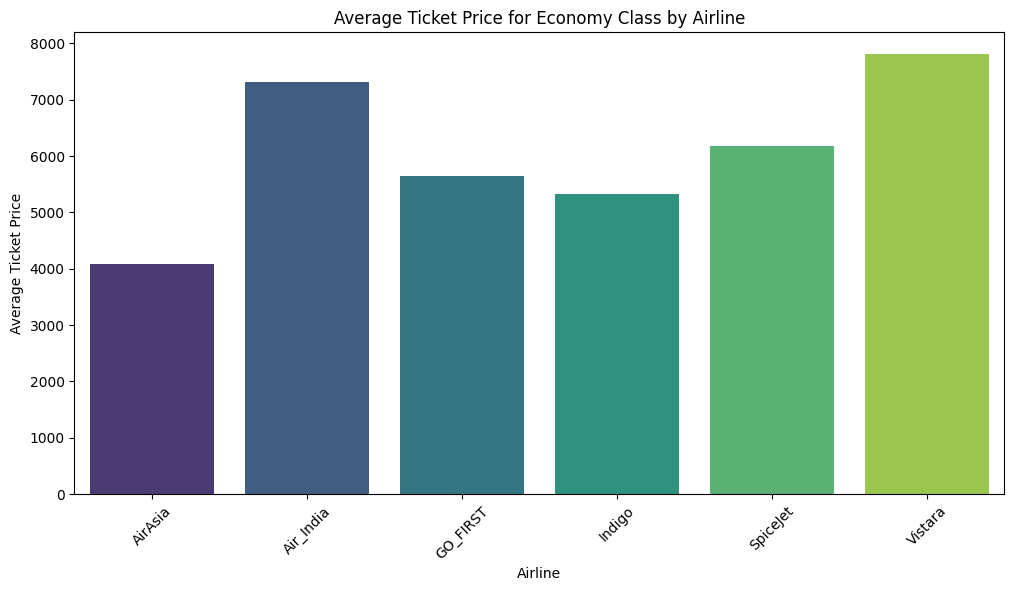

In [184]:

'''
Диаграмма по стоимости билетов в различным авиакомпаниях билетов эконом класса
'''

import seaborn as sns
import matplotlib.pyplot as plt

# Фильтруем данные по эконом-классу
economy_class_data = dop_df[dop_df['class'] == 'Economy']

# Группируем данные по авиакомпаниям и вычисляем среднюю стоимость билетов эконом класса для каждой компании
average_prices = economy_class_data.groupby('airline')['price'].mean().reset_index()

# Строим график
plt.figure(figsize=(12, 6))
sns.barplot(x='airline', y='price', data=average_prices, palette='viridis')
plt.title('Average Ticket Price for Economy Class by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Ticket Price')
plt.xticks(rotation=45)
plt.show()

##Conclusion: business class prices are higher than economy class, however, for a more objective consideration, it is necessary to consider a certain company and its assigned route. However, earlier, having considered the thermal correlation matrix, it was concluded that

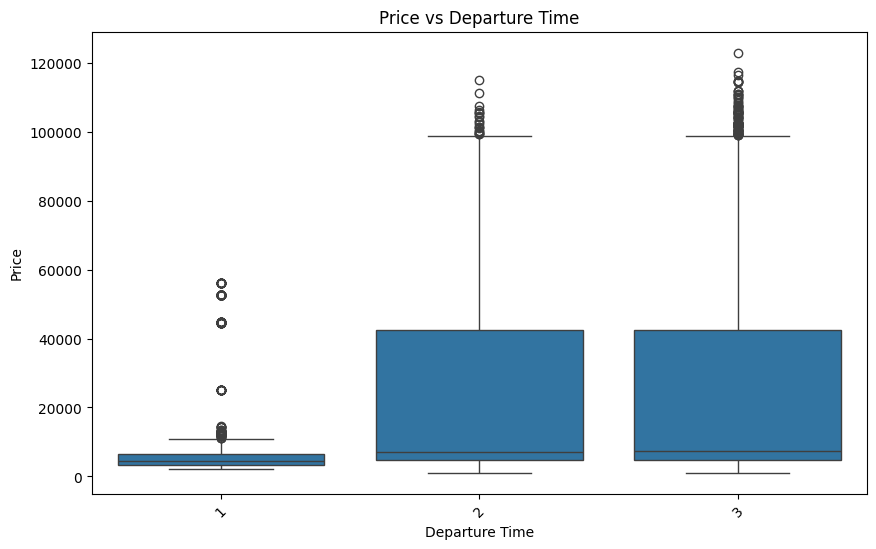

In [185]:
#  Зависимость цены билета от времени вылета
plt.figure(figsize=(10, 6))
sns.boxplot(x='departure_time', y='price', data=df)
plt.title('Price vs Departure Time')
plt.xlabel('Departure Time')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

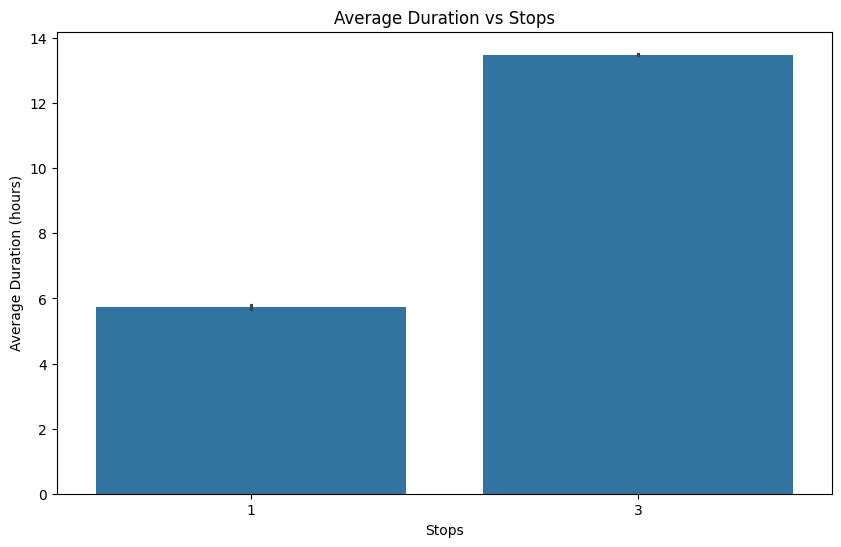

In [186]:
plt.figure(figsize=(10, 6))
sns.barplot(x='stops', y='duration', data=df, estimator=lambda x: sum(x) / len(x))
plt.title('Average Duration vs Stops')
plt.xlabel('Stops')
plt.ylabel('Average Duration (hours)')
plt.show()

### 3.4 Linear Regression:
- Perform linear regression to predict ticket prices based on relevant independent variables. Choose variables that are likely to influence the ticket price.
- Evaluate the results using R squared (coefficient of determination) to assess the goodness of fit of the regression model.
- Provide interpretation of the coefficients and discuss the overall performance of the model.

In [187]:
df=df.dropna()
from sklearn.linear_model import LinearRegression
X = df.drop(['price', 'index'], axis=1)

X=X.dropna()
y = df['price']
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 50368838.59640449
R-squared: 0.9022879327203969


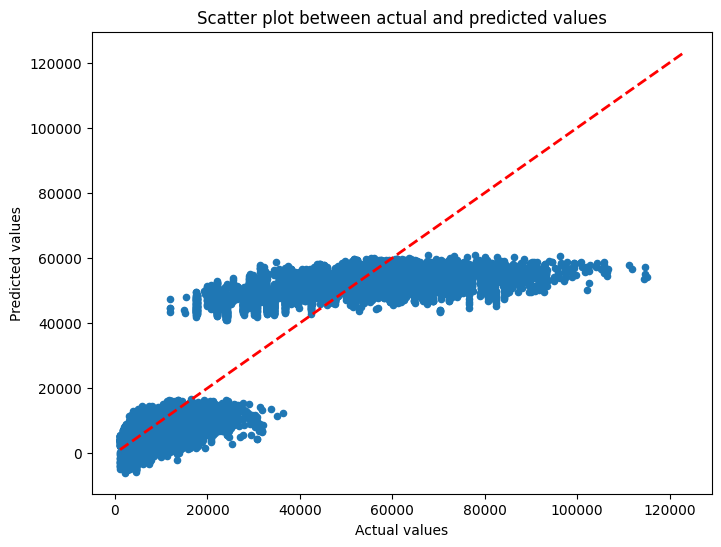

In [188]:
# Построение графика рассеяния
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, s=20)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Scatter plot between actual and predicted values")
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', linewidth=2)
plt.show()

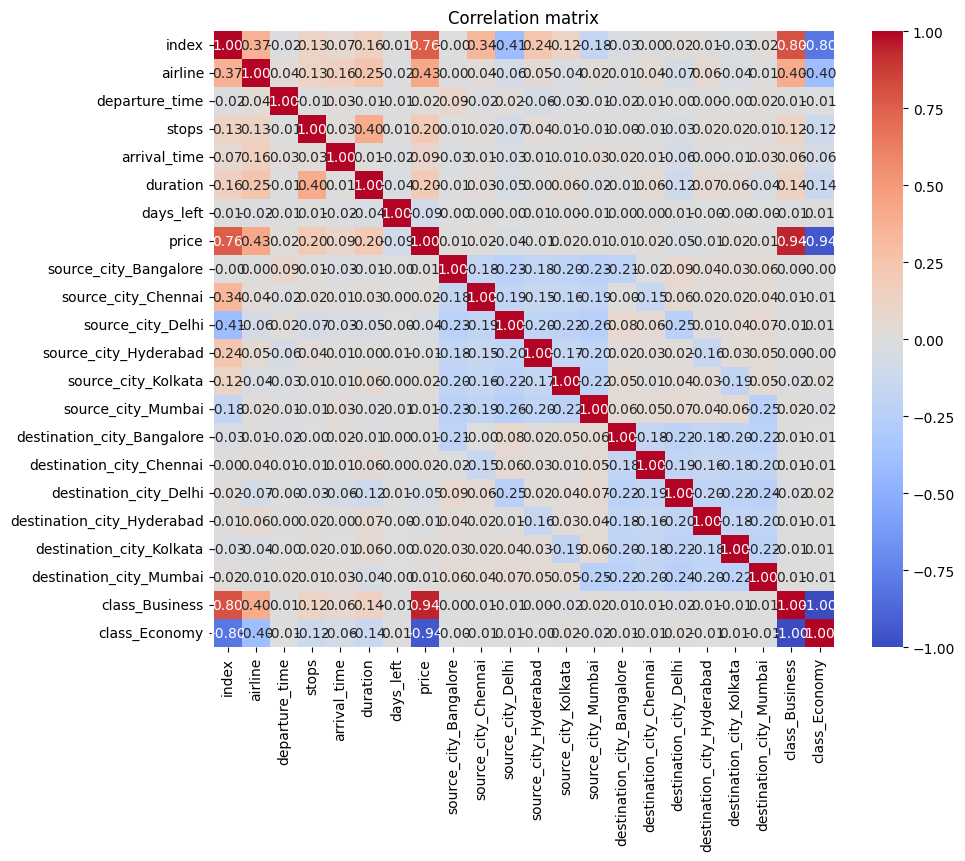

In [189]:
from sklearn.ensemble import RandomForestRegressor


# Создаем корреляционную матрицу
correlation_matrix = df.corr()

# Визуализируем матрицу корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation matrix")
plt.show()


rf_model = RandomForestRegressor()
rf_model.fit(X, y)

# Получаем важности признаков
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)


In [190]:
print(feature_importances)
'''
Проанализировав таблицу ниже можно сделать вывод, что сильнее всего на стоимость билетов влияет класс пассажира,
в котором он летит
'''

                       Feature  Importance
19               class_Economy    0.475246
18              class_Business    0.404868
4                     duration    0.060300
5                    days_left    0.018601
0                      airline    0.011267
3                 arrival_time    0.005711
17     destination_city_Mumbai    0.003198
14      destination_city_Delhi    0.003154
8            source_city_Delhi    0.002583
1               departure_time    0.001794
6        source_city_Bangalore    0.001761
2                        stops    0.001679
9        source_city_Hyderabad    0.001629
16    destination_city_Kolkata    0.001314
12  destination_city_Bangalore    0.001205
15  destination_city_Hyderabad    0.001187
13    destination_city_Chennai    0.001176
11          source_city_Mumbai    0.001124
10         source_city_Kolkata    0.001116
7          source_city_Chennai    0.001089


'\nПроанализировав таблицу ниже можно сделать вывод, что сильнее всего на стоимость билетов влияет класс пассажира,\nв котором он летит\n'

In [191]:


df['air_class_1'] = df['class_Business'] * df['airline']
df['air_class_2'] = df['class_Economy'] * df['airline']

In [192]:
X = df.drop(['price', 'index'], axis=1)

X=X.dropna()
y = df['price']
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Оценка качества модели
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')


Mean Squared Error: 45983061.74767098
R-squared: 0.910796036827196


## And now I will provide interpretation of the coefficients by representing the weights by which each of the variables is multiplied to get the predicted value of the dependent variable.

In [193]:
print(model.summary())

[ 2.22010718e+15  5.18250000e+02  2.16204726e+03  4.01869657e+02
  1.25050710e+02 -1.32813990e+02 -4.38610682e+13 -4.38610682e+13
 -4.38610682e+13 -4.38610682e+13 -4.38610682e+13 -4.38610682e+13
 -1.19725112e+13 -1.19725112e+13 -1.19725112e+13 -1.19725112e+13
 -1.19725112e+13 -1.19725112e+13  3.01720602e+11  3.01720603e+11
 -2.22010718e+15 -2.22010718e+15]


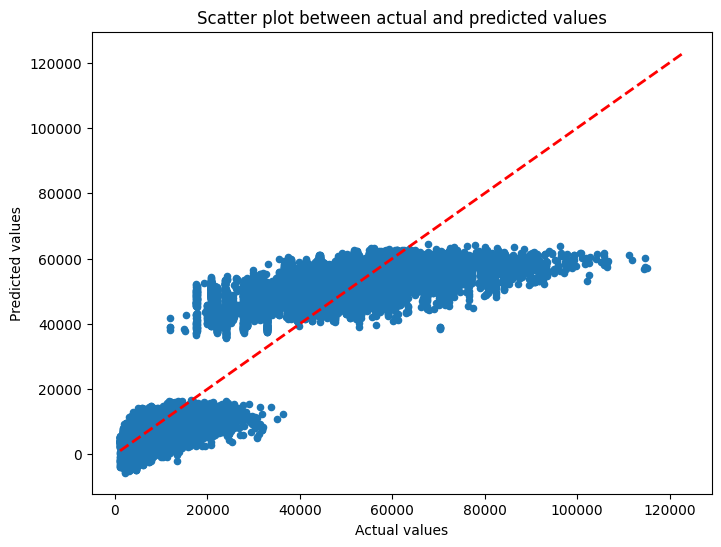

In [194]:
# Построение графика рассеяния
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, s=20)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Scatter plot between actual and predicted values")
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', linewidth=2)
plt.show()

##Conclusion:R-squared: 0.910796036827196, which is an indicator that the model is working well, as well as the above is a scattering graph, considering which it can be concluded that the model is working well.

## Task 4. Classification (3 points)

Given the Dataset in `task_4.csv` make some necessary transformations and train the model to classify the obesity type.

### Dataset Description

The data contains 17 attributes and 2111 records, the records are labeled with the **class variable NObesity (Obesity Level), that allows classification of the data** using the values of Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II and Obesity Type III.

The attributes related with eating habits are: Frequent consumption of high caloric food (FAVC), Frequency of consumption of vegetables (FCVC), Number of main meals (NCP), Consumption of food between meals (CAEC), Consumption of water daily (CH20), and Consumption of alcohol (CALC). The attributes related with the physical condition are: Calories consumption monitoring (SCC), Physical activity frequency (FAF), Time using technology devices (TUE), Transportation used (MTRANS), other variables obtained were: Gender, Age, Height and Weight.

**Questions of the survey used for initial recollection of information**

Question (Possible Answers)

* What is your gender?	•Female •Male
* What is your age?	Numeric value
* What is your height?	Numeric value in meters
* What is your weight?	Numeric value in kilograms
* Has a family member suffered or suffers from overweight?	•Yes •No
* Do you eat high caloric food frequently? •Yes •No
* Do you usually eat vegetables in your meals?	•Never •Sometimes •Always
* How many main meals do you have daily?	•Between 1 y 2 •Three •More than three
* Do you eat any food between meals? •No •Sometimes •Frequently •Always
* Do you smoke? •Yes •No
* How much water do you drink daily? •Less than a liter •Between 1 and 2 L •More than 2 L
* Do you monitor the calories you eat daily? •Yes •No
* How often do you have physical activity? •I do not have •1 or 2 days •2 or 4 days •4 or 5 days
* How much time do you use technological devices such as cell phone, videogames, television, computer and others? •0–2 hours •3–5 hours •More than 5 hours
* How often do you drink alcohol? •I do not drink •Sometimes •Frequently •Always
* Which transportation do you usually use? •Automobile •Motorbike •Bike •Public Transportation •Walking


### 4.1 Data Preparation:

- Identify and handle missing values, outliers, or any other data quality issues.
- Convert categorical variables into a suitable format for modeling.
- Discuss any decisions made during the data cleaning process.

In [195]:
df=pd.read_csv('task_4.csv',delimiter=',')
pd.read_csv('task_4.csv',delimiter=',')[:5]

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [196]:
# Проверка наличия NaN значений во всем датасете
nan_values = df.isna().sum()
print(nan_values)


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


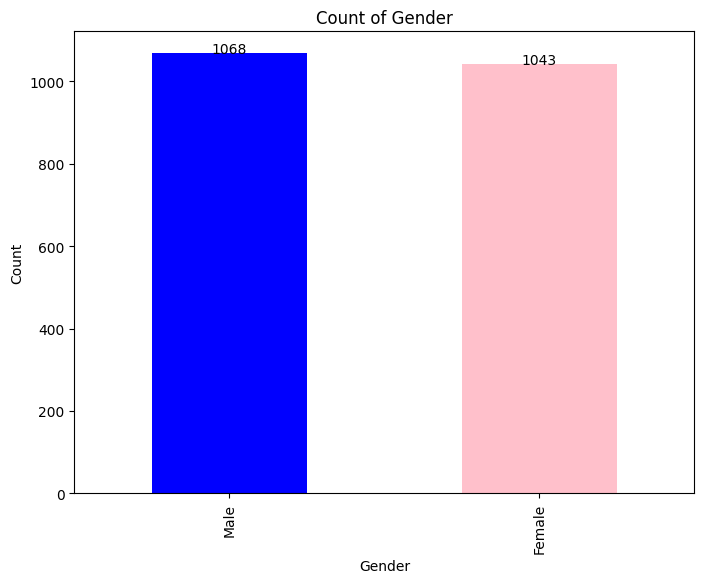

In [197]:
import matplotlib.pyplot as plt

# Подсчет количества встречающихся мужчин и женщин
gender_counts = df['Gender'].value_counts()

# Создам диаграмму
plt.figure(figsize=(8, 6))
gender_counts.plot(kind='bar', color=['blue', 'pink'])

plt.title('Count of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

for i, count in enumerate(gender_counts):
    plt.text(i, count + 0.1, str(count), ha='center')

plt.show()


##The chart above shows that the amount of data on men and women is approximately the same.

##I will create a dot plot based on data on the height of men and women.

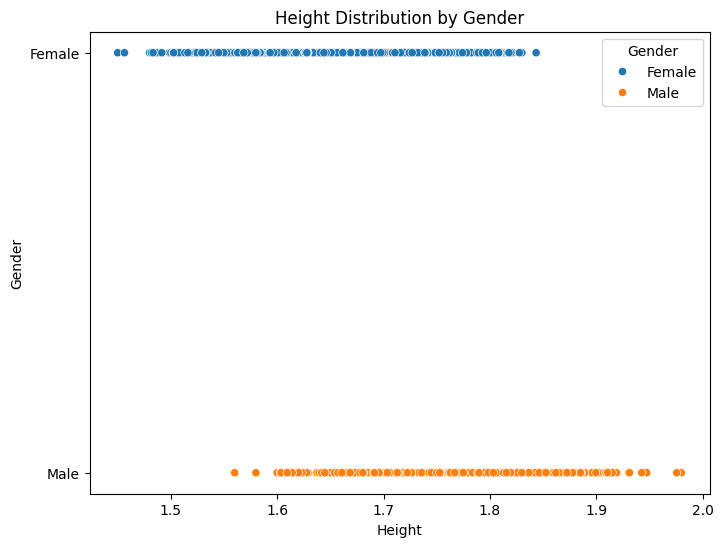

In [198]:
"""
        Точечный график на основе данных о росте мужчин и женщин
"""


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Height', y='Gender', hue='Gender')

plt.title('Height Distribution by Gender')
plt.xlabel('Height')
plt.ylabel('Gender')


plt.legend(title='Gender')

plt.show()


##It can be seen from the plot above that the range for the distribution of height for men and women is different.

##I will create a dot plot based on data on the weight of men and women.

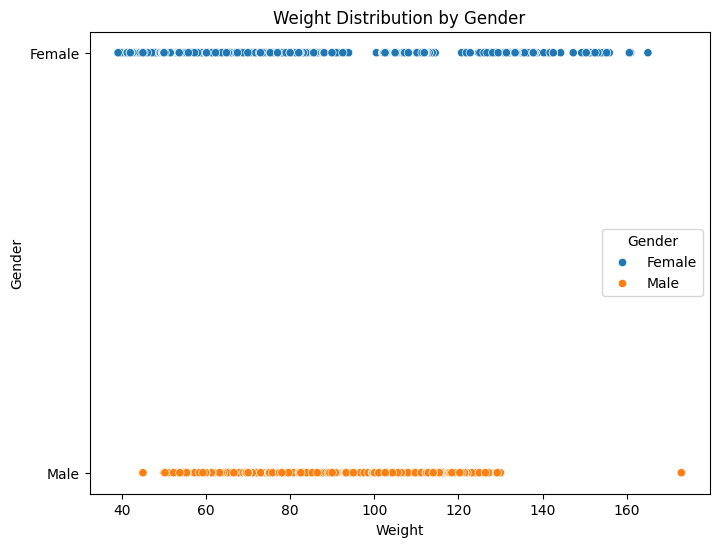

In [199]:
"""
        Точечный график на основе данных о весе мужчин и женщин
"""



import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Weight', y='Gender', hue='Gender')
plt.title('Weight Distribution by Gender')
plt.xlabel('Weight')
plt.ylabel('Gender')

plt.legend(title='Gender')

plt.show()

##It can be seen from the graph above that the range for weight distribution for men and women is different. For women, the range of weights found on this dataset is much wider.

##From the plot above, we can assume the theory that there is an outlier at point 173 in the men's weight data. I'm going to test this theory now.

In [200]:
# Получаем два минимальных и два максимальных веса для каждого пола.

"""
Беру по 2 т.к. на графике выше с, этим я прооверяю терию о том является ли это выбросом

"""

min_max_weight = df.groupby('Gender')['Weight'].agg(lambda x: x.nsmallest(2).tolist() + x.nlargest(2).tolist())

# Выводим результаты
print("Two minimum and two maximum weights:")
print(min_max_weight)



Two minimum and two maximum weights:
Gender
Female    [39.0, 39.101805, 165.057269, 160.935351]
Male                     [45.0, 45.0, 173.0, 130.0]
Name: Weight, dtype: object


The theory was confirmed: the value in weight 173 is an outlier.

From the graphs above, it can be seen that men have a minimum height greater than women, and the maximum is greater. However, the weight range for men is narrower (from 45 to 130) than for women (from 39 to 160.935351).

##Now I  will build the plot using the NObesity parameter, but I will split it separately into men and women.

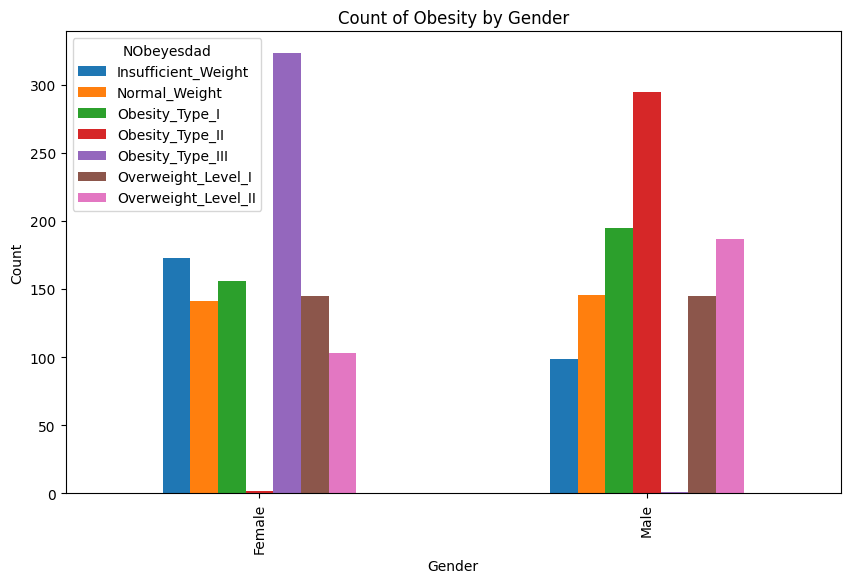

In [201]:
"""
          Подсчет количества наблюдений по параметру "NObeyesdad" для каждого пола
"""


gender_obesity_counts = df.groupby('Gender')['NObeyesdad'].value_counts().unstack()

gender_obesity_counts.plot(kind='bar', figsize=(10, 6))

plt.title('Count of Obesity by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


Conclusions based on this graph: Obesity_Type_III almost does not occur in men, and Obesity_Type_II almost does not occur in women. However, Obesity_Type_III is most common in women, and most common in men is Obesity_Type_II.

As a result, what occurs most often in men is less common in women and vice versa

##In connection with the conclusions made above, I will divide the dataset into datasets according to the parameters of men and women. I.e. I will have 2 datasets : male and female.+ the amount of data on men and women is almost the same amount (information from the 1 chart).However, for convenience, I will do this at the end of the data conversion.

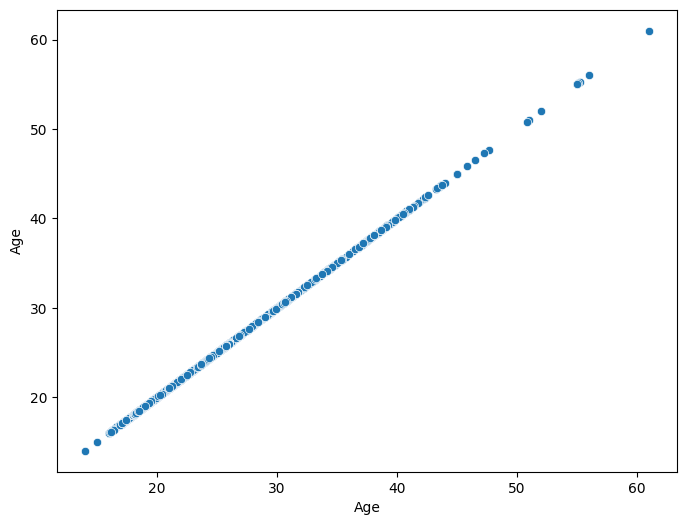

In [202]:
import seaborn as sns


# Создаем точечный график
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Age', y='Age')

plt.xlabel('Age')
plt.ylabel('Age')

# Показываем график
plt.show()


##The plot shows that there are people of different ages in the dataset

##There is also a data scaling problem on this dataset - Age,Height, Weight. Because of this, problems may arise in the future.
##The solution to the problem: I will add an additional feature - the average body mass index (BMI), this feature displays just the height and weight of a person.

In [203]:
# Создаем новый столбец 'BMI' в df
df['BMI'] = df['Weight'] / (df['Height']) ** 2

print(df.head())


   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad        BMI  
0  Public_Transportation        Normal_Weight  24.386526  
1  Public_Transportation        Normal_Weight  24.238227  

In [204]:
'''
Т.к. данные о весе и росте отображены в BMI, то для решения проблемы масштабирования данных,
я удалю значения о росте и весе без каких-либо потерь из датасета
'''

columns_to_drop = ['Height', 'Weight']

df = df.drop(columns=columns_to_drop, axis=1)


<ipython-input-205-db6f50f3457f>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


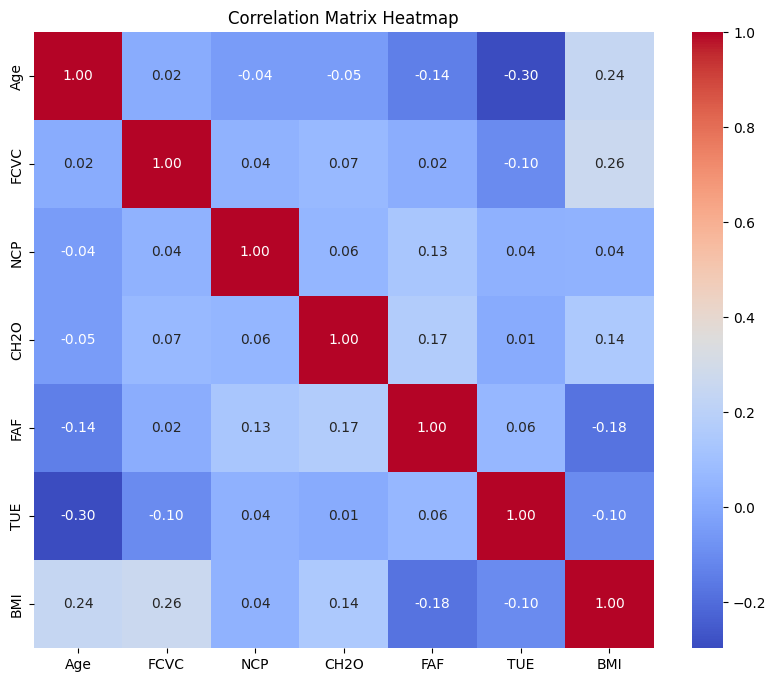

In [205]:


# Создание корреляционной матрицы
correlation_matrix = df.corr()

# Создание тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Matrix Heatmap')
plt.show()


##I transform categorical parameters (which have no internal order between the values of a categorical variable) using OHE.


In [206]:
#ohe

df = pd.get_dummies(df, columns=['family_history_with_overweight','FAVC','SMOKE','SCC','MTRANS'], prefix=['family_history_with_overweight','FAVC','SMOKE','SCC','MTRANS'])


##The remaining parameters clearly show the internal relationship between the values of these variables. Therefore, I transform the data below using Label_Encoder.

###I will build a chart based on data on the frequency of food consumed between meals.

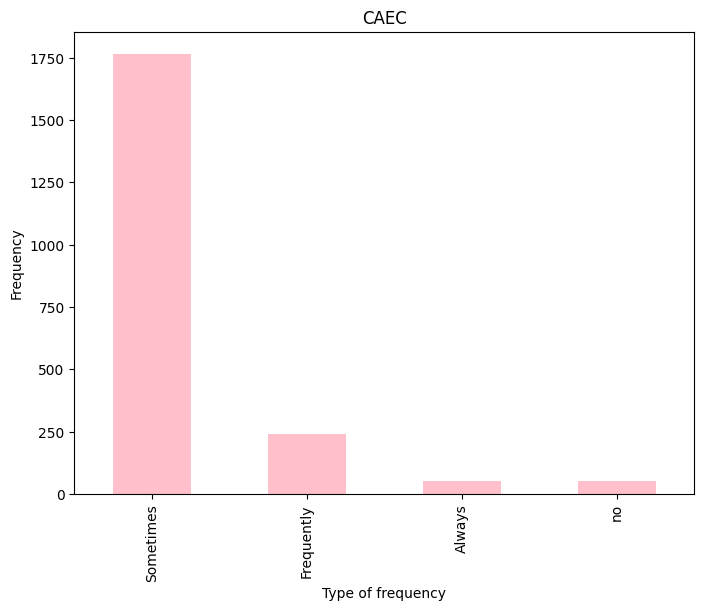

In [207]:
CAEC_counts = df['CAEC'].value_counts()

# Построение диаграммы
plt.figure(figsize=(8, 6))
CAEC_counts.plot(kind='bar', color='pink')
plt.title('CAEC')
plt.xlabel('Type of frequency')
plt.ylabel('Frequency')
plt.show()

In [208]:
from sklearn.preprocessing import LabelEncoder
"""
Преобразование частоты потребления пищи между приемами пищи
"""

priorities = {'no': 0, 'Sometimes': 3, 'Frequently': 5,'Always':7}

# Применяю Label Encoding с учетом приоритетов
label_encoder = LabelEncoder()
df['CAEC'] = df['CAEC'].map(lambda x: priorities[x])


###I will build a chart based on data on the frequency of alcohol consumption.

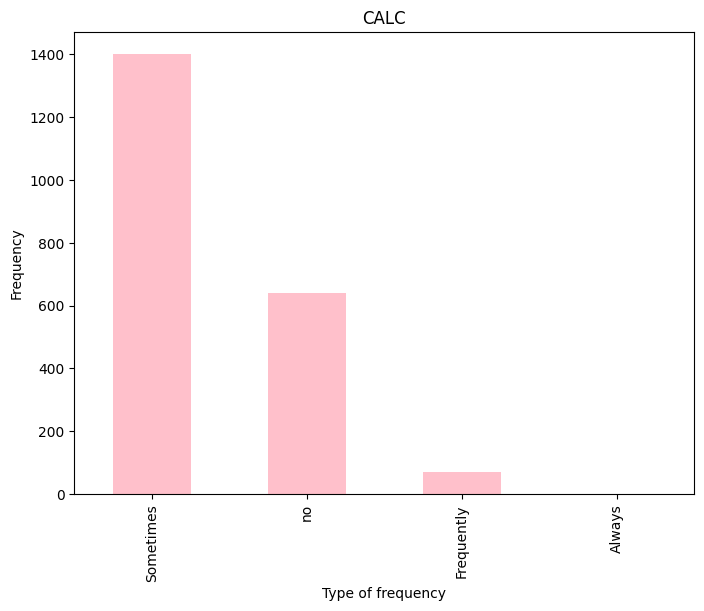

In [209]:
CALC_counts = df['CALC'].value_counts()

# Построение диаграммы
plt.figure(figsize=(8, 6))
CALC_counts.plot(kind='bar', color='pink')
plt.title('CALC')
plt.xlabel('Type of frequency')
plt.ylabel('Frequency')
plt.show()

##it can be seen from the graph that either a very small number of people always drink alcohol, or not 1, I will check this

In [210]:
count = df['CALC'].value_counts().get('Always', 0)
print(count)

1


In [211]:
from sklearn.preprocessing import LabelEncoder


"""
Преобразование частоты потребления алкоголя
"""


priorities = {'no': 0, 'Sometimes': 3, 'Frequently': 5,'Always':7}

# Применение Label Encoding с учетом приоритетов
label_encoder = LabelEncoder()
df['CALC'] = df['CALC'].map(lambda x: priorities[x])

##I will check if all categorical columns have been converted. Only the target column should remain categorical.

In [212]:
categorical_columns = df.select_dtypes(include=['object']).columns

# Выводим названия столбцов с категориальными данными
print("Columns with categorical data:",categorical_columns)


Columns with categorical data: Index(['Gender', 'NObeyesdad'], dtype='object')


##Everything is fine with the data now (there is no point in converting the Gender column, because I will divide it into 2 datasets: a male dataset and a female dataset). The reasons and explanations were given above.

##I will build a thermal correlation matrix to study the correlation relationships between variables.

<ipython-input-213-6ef4f84ecc2c>:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


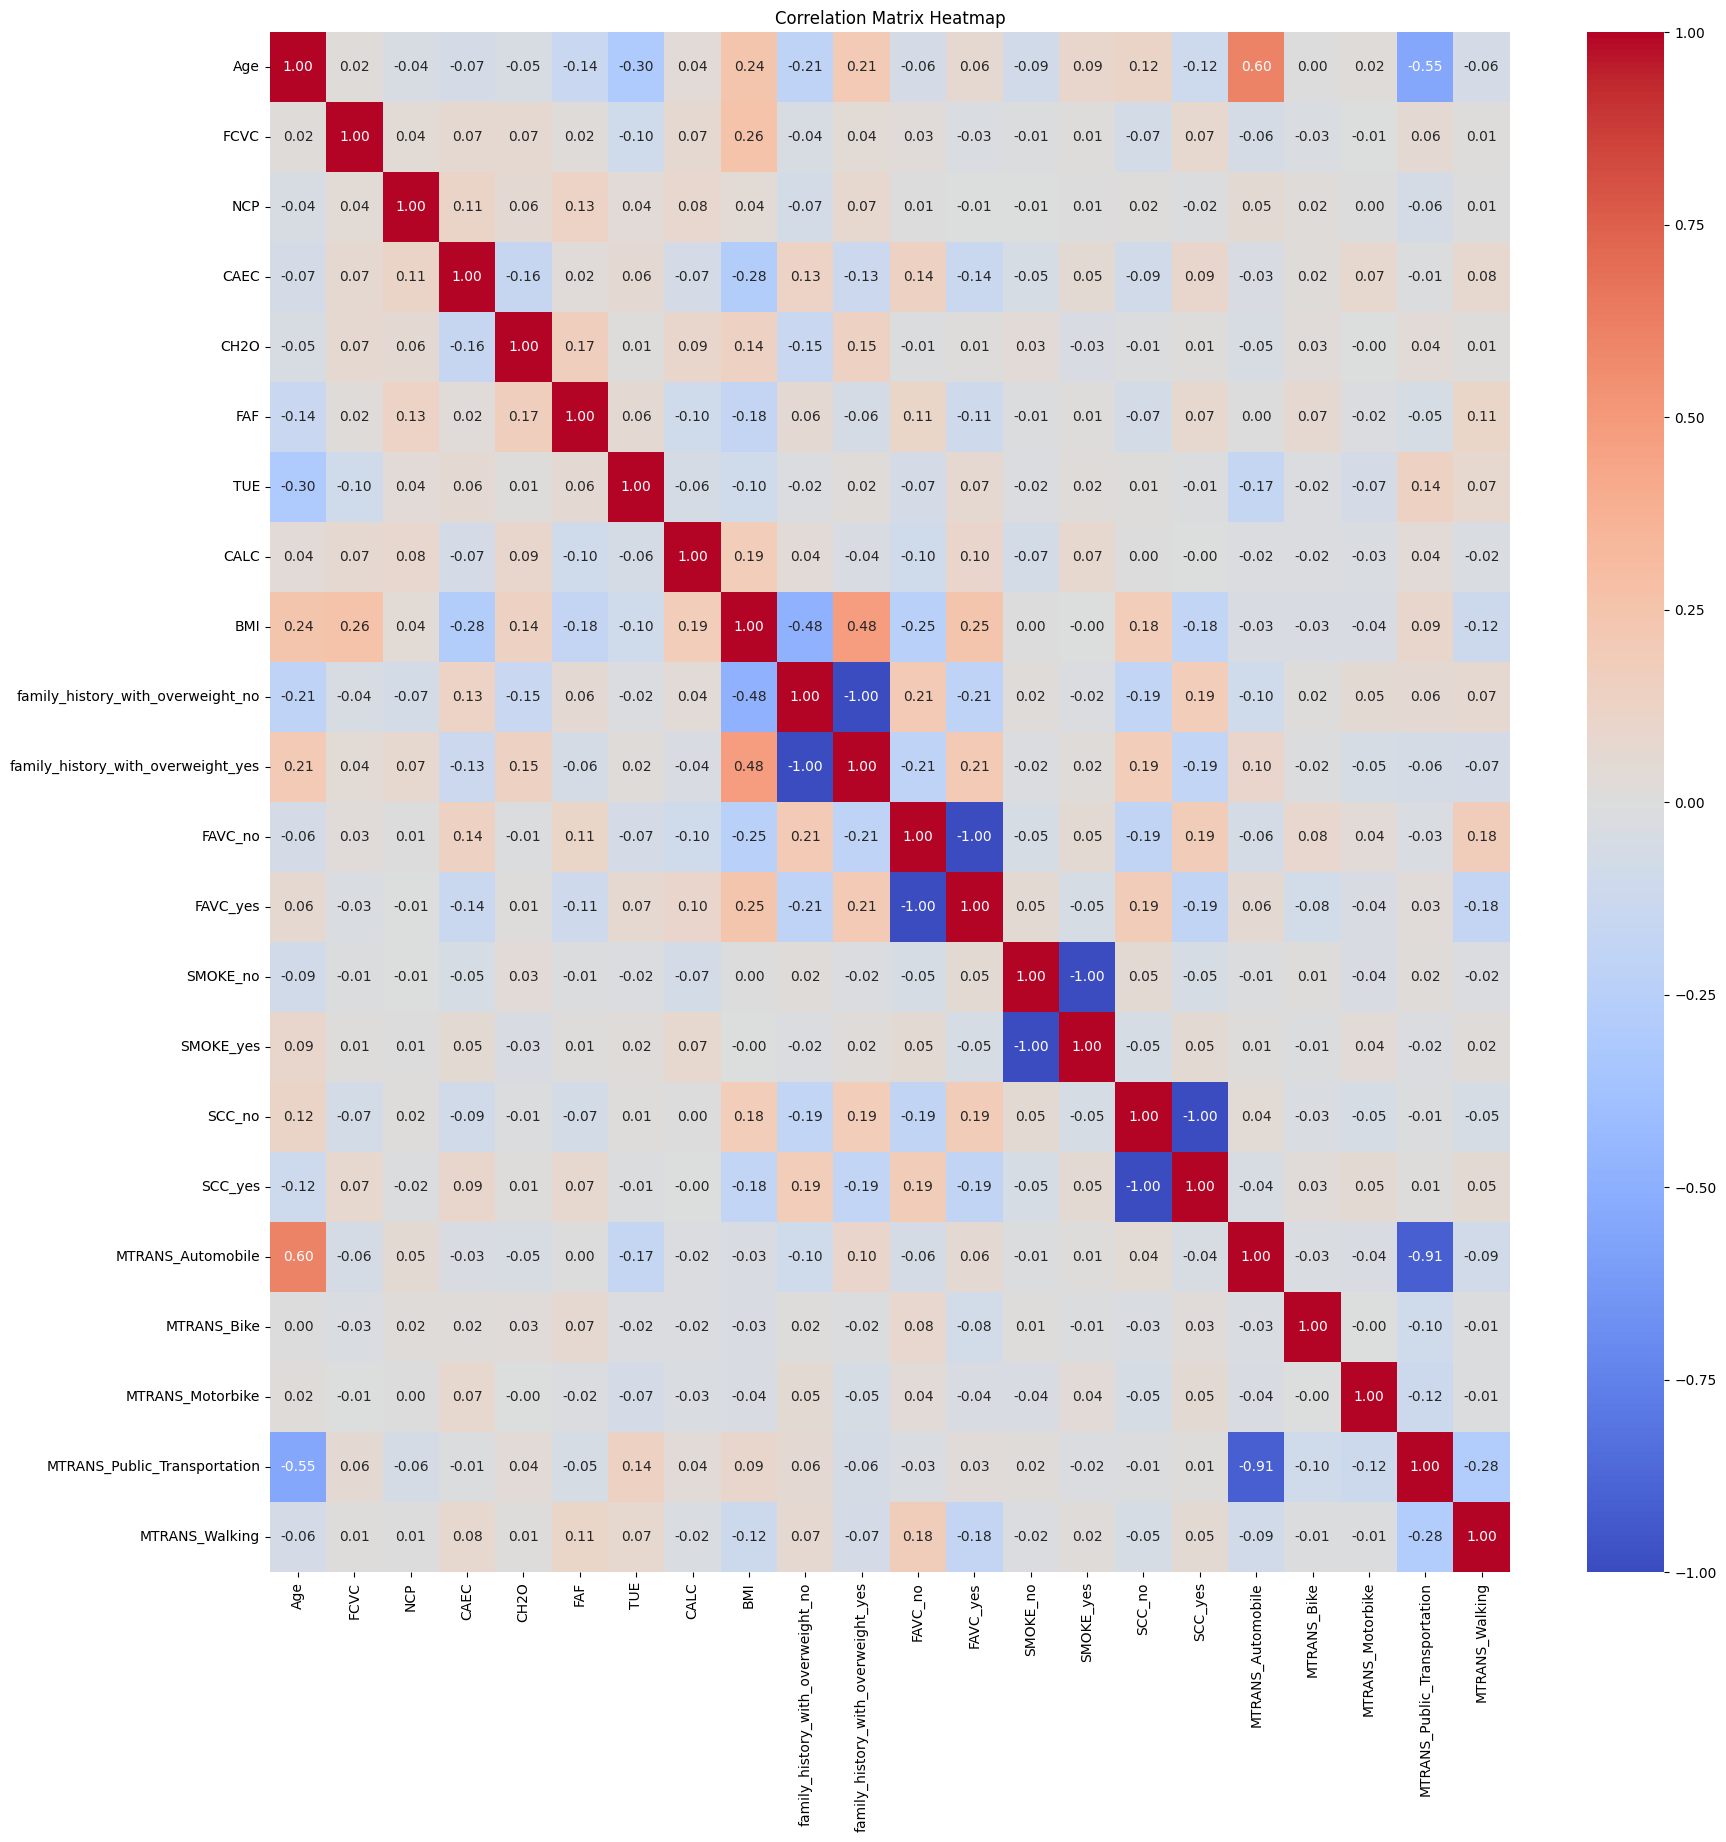

In [213]:
import seaborn as sns
import matplotlib.pyplot as plt

# Создание корреляционной матрицы
correlation_matrix = df.corr()

# Создание тепловой карты
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Matrix Heatmap')

plt.show()

##Having studied the thermal correlation matrix, it can be concluded that the following parameters affect the BMI parameter the most:Age,FCVC, CALC, FAVC_yes, family_history_with_overweight_yes, SCC, MTRANS.

In [214]:
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']

##Everything with data is fine now.

### 4.2 Training and Hyperparameter Tuning::

- Select a classification model for predicting 'NObeyesdad'
- Split the dataset into training and testing sets.
- Train the chosen model on the training set.

### 4.3 Model Evaluation:

- Evaluate the trained model on the testing set.
- Choose appropriate evaluation metrics for a classification task (e.g., accuracy, precision, recall, F1-score).

##Because I have divided the dataset into 2 datasets: a male dataset and a female dataset. Therefore, I will perform steps 4.2 and 4.3 sequentially for each dataset.

In [215]:
# Разделение данных на обучающий и тестовый наборы

'''
              Для мужчин
'''


y_men = male_df['NObeyesdad']
X_men=male_df.drop(['NObeyesdad','Gender'], axis=1)
X_train_men, X_test_men, y_train_men, y_test_men = train_test_split(X_men, y_men, test_size=0.2, random_state=42)


In [216]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


# Создаем модель SVC
svc = SVC()
svc.fit(X_train_men, y_train_men)

SVC()

In [217]:
y_pred_men = svc.predict(X_test_men)
accuracy = accuracy_score(y_test_men, y_pred_men)
print(f"SVC Test Accuracy: {accuracy}")

SVC Test Accuracy: 0.9205607476635514


In [218]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test_men, y_pred_men, average='micro')
recall = recall_score(y_test_men, y_pred_men, average='micro')
f1 = f1_score(y_test_men, y_pred_men, average='micro')

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Precision: 0.9205607476635514
Recall: 0.9205607476635514
F1-score: 0.9205607476635514


In [219]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

param_grid = {'C': [0.1, 1, 11], 'gamma': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}


# Создаем модель SVC
svc = SVC()


# Поиск по сетке гиперпараметров+cross-validation(разбила данные на 3 части(складки))
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=3)
grid_search.fit(X_train_men, y_train_men)

# Получение наилучших гиперпараметров
best_params = grid_search.best_params_
print(f"Best hyperparameters: {best_params}")

# Оценка наилучшей модели на тестовом наборе данных
best_model = grid_search.best_estimator_
best_model.fit(X_train_men, y_train_men)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best hyperparameters: {'C': 1, 'gamma': 0.1, 'kernel': 'linear'}


SVC(C=1, gamma=0.1, kernel='linear')

In [220]:
y_pred = best_model.predict(X_test_men)
accuracy = accuracy_score(y_test_men, y_pred_men)
print(f"SVC Test Accuracy for men's dataset: {accuracy}")

SVC Test Accuracy for men's dataset: 0.9205607476635514


In [221]:
precision = precision_score(y_test_men, y_pred_men, average='micro')
recall = recall_score(y_test_men, y_pred_men, average='micro')
f1 = f1_score(y_test_men, y_pred_men, average='micro')

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Precision: 0.9205607476635514
Recall: 0.9205607476635514
F1-score: 0.9205607476635514


In [222]:
'''
            Для женщин
'''

y_women = female_df['NObeyesdad']
X_women=female_df.drop(['NObeyesdad','Gender'], axis=1)
X_train_women, X_test_women, y_train_women, y_test_women = train_test_split(X_women, y_women, test_size=0.2, random_state=42)


In [223]:

# Создаем модель SVC
svc = SVC()
svc.fit(X_train_women, y_train_women)

SVC()

In [224]:
y_pred_women = svc.predict(X_test_women)
accuracy = accuracy_score(y_test_women, y_pred_women)
print(f"SVC Test Accuracy: {accuracy}")

SVC Test Accuracy: 0.8708133971291866


In [225]:
precision = precision_score(y_test_women, y_pred_women, average='micro')
recall = recall_score(y_test_women, y_pred_women, average='micro')
f1 = f1_score(y_test_women, y_pred_women, average='micro')

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Precision: 0.8708133971291866
Recall: 0.8708133971291866
F1-score: 0.8708133971291866


In [226]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

param_grid = {'C': [0.1, 1, 11], 'gamma': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svc = SVC()

grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=3)
grid_search.fit(X_train_women, y_train_women)

best_params = grid_search.best_params_
print(f"Best hyperparameters: {best_params}")

best_model = grid_search.best_estimator_
best_model.fit(X_train_women, y_train_women)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Best hyperparameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}


SVC(C=1, gamma=0.1)

In [227]:
y_pred_women = best_model.predict(X_test_women)
accuracy = accuracy_score(y_test_women, y_pred_women)
print(f"SVC Test Accuracy for women's dataset: {accuracy}")

SVC Test Accuracy for women's dataset: 0.9808612440191388


In [228]:
precision = precision_score(y_test_women, y_pred_women, average='micro')
recall = recall_score(y_test_women, y_pred_women, average='micro')
f1 = f1_score(y_test_women, y_pred_women, average='micro')

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.9808612440191388
Recall: 0.9808612440191388
F1-score: 0.9808612440191388


#To assess how good the result turned out above, I will create an SVC model, which I will train on the initial dataset, converting all categorical data using OHE

In [229]:
df=pd.read_csv('task_4.csv',delimiter=',')
pd.read_csv('task_4.csv',delimiter=',')[:5]

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [230]:
df = pd.get_dummies(df, columns=['MTRANS','CALC','CAEC','Height',	'Weight','Gender','Age','family_history_with_overweight','FAVC','SMOKE','SCC'], prefix=['MTRANS','CALC','CAEC','Height',	'Weight','Gender','Age','family_history_with_overweight','FAVC','SMOKE','SCC'])


In [231]:
y = df['NObeyesdad']
X=df.drop(['NObeyesdad'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создаем модель SVC
svc = SVC()
svc.fit(X_train, y_train)

SVC()

In [232]:
y_pred = svc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"SVC Test Accuracy: {accuracy}")

SVC Test Accuracy: 0.6572104018912529


In [233]:
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')
f1 = f1_score(y_test, y_pred, average='micro')

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.6572104018912529
Recall: 0.6572104018912529
F1-score: 0.6572104018912529


#Conclusion:

##The best results:

##For a model that predicts NObeyesdad for men, the following results were obtained:
##Precision: **0.9205607476635514**
##Recall: **0.9205607476635514**
##F1-score: **0.9205607476635514**

##For a model that predicts NObeyesdad for women, the following results were obtained:
##Precision: **0.9808612440191388**
##Recall: **0.9808612440191388**
##F1-score:**0.9808612440191388**



##***These results are much better than ***
##Precision: 0.6572104018912529
##Recall: 0.6572104018912529
##F1-score: 0.6572104018912529

#**This confirms that the models are trained on well-prepared data and the model itself works well for this task.**